# 0. Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.tree import plot_tree

import scipy.stats as stats
from scipy.stats import randint
import statsmodels.api as sm

from scipy.stats import chi2_contingency, pointbiserialr
from dython.nominal import associations
from dython.nominal import associations

import markdown

import warnings
warnings.filterwarnings('ignore')


In [2]:
#font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']

In [3]:
#color palette
colors= ['#878787','#bca47c']


# 1. Case

## 1.1 Background

A bank in Portugal is conducting a Telemarketing program to offer Deposits to their customers. These deposits are important as a foundation of a bank’s ability to lend money or make investments. Current success rate (or we called it as conversion rate) is quite low, only 11.27% success from overall contacted customers. Based on the ROI calculation, it shows a negative direction of return, it lost 85% from the expense of cost marketing. The objective of this goal is to conduct data analysis and machine learning models to give insights into the strategic way of conducting telemarketing as well as selecting potential customer leads for deposit programs. By doing so, it will allow the bank to focus its efforts on high-potential leads and create some technical strategic telemarketing activities to increase the net profit, ROI and Conversion Rate of the campaign program.

### 1.1.1 How does the program generate profit?

The bank's revenue comes from the interest on bank deposits, which are used for investments or loan programs. This revenue is calculated after deducting marketing costs and the cost of using the deposits for the bank's programs. More detailed calculations will be explained in the modeling Jupyter notebook.

### 1.1.2 Stakeholders
- Chief Strategy Officer
This role involves researching and developing strategies to achieve company growth. They are responsible for investigating the factors that influence telemarketing efforts and their overall impact.

- Chief Financial Officer
The CFO is responsible for financial planning and management within the bank. This includes planning and managing the potential costs associated with deploying the machine learning model and the future telemarketing strategy.

- Chief Risk and Compliance Officer
This position ensures that the development of the machine learning model adheres to all regulations while minimizing potential risks.

- Chief Human Resources Officer
The CHRO is responsible for gathering and coordinating all the human resources necessary to support the development of the machine learning model and the future telemarketing strategy.

- Chief of Marketing
This role involves formulating specific marketing activities and ensuring high-quality efforts to reach more customer leads.


## 1.2 Problem Statement

Portugal Bank's current telemarketing program suffers from a low conversion rate and is not cost-effective. To improve this, the telemarketing team needs to implement a more efficient and effective strategy. The number of customer leads who do not subscribe to a deposit program should not exceed the number of successful conversions. To achieve this, a more selective and targeted approach to customer leads is necessary.

Therefore, this project will focus on the following:

1. Exploring potential features that are associated with a customer's decision to apply for a deposit program. This information can be used to develop future telemarketing strategies.

2. Developing an analysis and model to identify customers who are most likely to subscribe to a deposit. This will help the bank focus its telemarketing efforts more effectively.

# 2. EDA

## 2.1. Preliminary Data Inspection

### 2.1.1. Data Gathering and Generic Views

In [4]:
df_bank = pd.read_csv('bank-additional-full.csv', sep=';')

In [5]:
df_bank.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
df_bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
df_bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### 2.1.2. Unique Values of Each Column

In [8]:
print("Uniqe values of object columns\n")
print(df_bank.select_dtypes(include=['object']).nunique())

Uniqe values of object columns

job            12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month          10
day_of_week     5
poutcome        3
y               2
dtype: int64


In [9]:
print("Job:",df_bank.job.value_counts(), "\n")
print("-"*25)
print("Marital:",df_bank.marital.value_counts(), "\n")
print("-"*25)
print("Education:",df_bank.education.value_counts(), "\n")
print("-"*25)
print("Default:",df_bank.default.value_counts(), "\n")
print("-"*25)
print("Housing loan:",df_bank.housing.value_counts(),"\n")
print("-"*25)
print("Personal loan:",df_bank.loan.value_counts(), "\n")
print("-"*25)
print("Contact:",df_bank.contact.value_counts(), "\n")
print("-"*25)
print("Month contacted:",df_bank.month.value_counts(), "\n")
print("-"*25)
print("Day contacted:",df_bank.day_of_week.value_counts(), "\n")
print("-"*25)
print("Previous outcome:",df_bank.poutcome.value_counts(), "\n")
print("-"*25)
print("Outcome of this campaign:",df_bank.y.value_counts(), "\n")
print("-"*25)

Job: job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64 

-------------------------
Marital: marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64 

-------------------------
Education: education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64 

-------------------------
Default: default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64 

-------------------------
Housing loan: housing
yes        21576
no         18622
unknown      990
Name: count, dty

## 2.2. Handling Null/Missing/Unknown values

### 2.2.1 Handling Null/Missing values

In [10]:
nullval = df_bank.isnull().sum()
nullval

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

No null values were found within the data.

### 2.2.2 Handling Unknown values

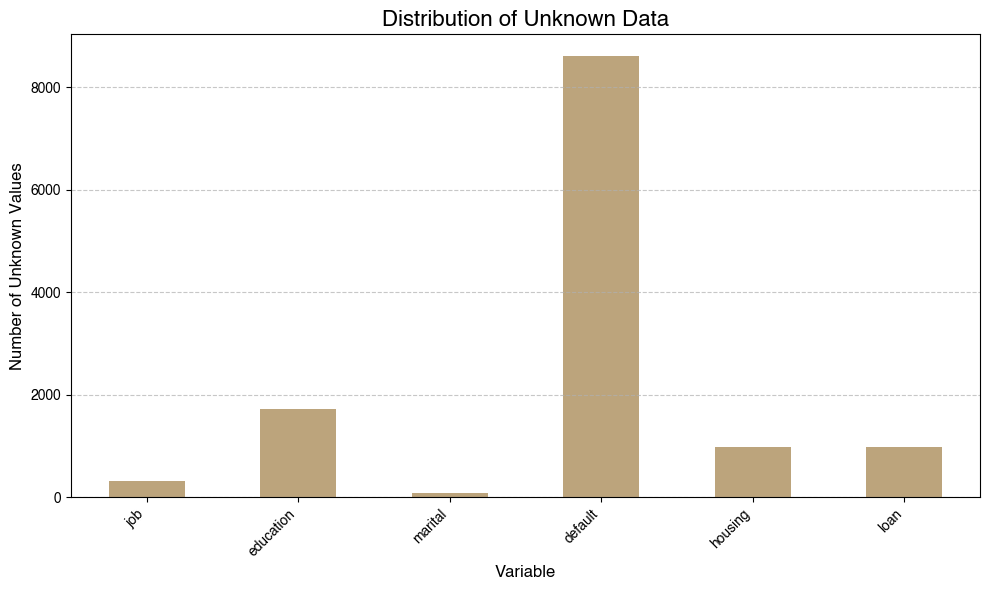

In [11]:
columns_to_check = ['job', 'education', 'marital', 'default', 'housing', 'loan']

unknown_counts = {}
for col in columns_to_check:
    unknown_counts[col] = (df_bank[col] == 'unknown').sum()

unknown_distribution = pd.Series(unknown_counts)

plt.figure(figsize=(10, 6))
unknown_distribution.plot(kind='bar', color='#bca47c')
plt.title('Distribution of Unknown Data', fontsize=16)
plt.xlabel('Variable', fontsize=12)
plt.ylabel('Number of Unknown Values', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

In [12]:
for i in columns_to_check:
    print(f'Percentage of people with unknown data {i}')
    print(((df_bank[i]=='unknown').sum()/(df_bank[i]).count()*100).round(3),'%')

Percentage of people with unknown data job
0.801 %
Percentage of people with unknown data education
4.203 %
Percentage of people with unknown data marital
0.194 %
Percentage of people with unknown data default
20.873 %
Percentage of people with unknown data housing
2.404 %
Percentage of people with unknown data loan
2.404 %


The high aggregate numbers in certain parts are largely due to unknown values. Therefore, we've decided to keep this unknown data for all features, as it may hold important insights for the analysis.

### 2.2.3 Handling Duplicate Data

In [13]:
print("Total of duplicated data is", df_bank.duplicated().sum())
pct_duplicated = (df_bank.duplicated().sum() / len(df_bank) * 100).round(2)
print("The percentage of duplicated data is", pct_duplicated,'%')

Total of duplicated data is 12
The percentage of duplicated data is 0.03 %


In [14]:
df_bank[df_bank.duplicated(keep='first')]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,no
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no


In [15]:
df_bank.drop_duplicates(inplace=True)
df_bank.shape

(41176, 21)

## 2.3 Normality check for Numerical Data

In [16]:
numerical_vars = [
    'age', 'duration', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'
]
categorical_vars = [
    'job', 'marital', 'education', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome', 'age_group'
]

In [17]:
for j in numerical_vars :
    fig = px.histogram(df_bank, x=j, histnorm='probability density',color_discrete_sequence=['#bca47c'])
    fig.show()


Based on the histogram, the distribution of the numerical data is not a normal distribution. This means that the choice of statistical measurements should be adjusted for non-normal data.



## 2.4 Transforming some Numerical Data into Categorical Data

To provide better information about the data, some variables will be converted into categorical data. These are:

- age: Will be grouped into 5-year intervals to better capture if there is a specific age range that commits to bank deposits.

- campaign: Will be grouped into "1 call,", "2 calls,", "3 calls,", "4 calls,", "5 calls,", "More than 5 calls,"." This will show the possibility of a successful "one-shot" call and whether other call frequencies are acceptable.

- previous: Will be grouped into "0 call, 1 call,", "2 calls,", "3 calls,", "4 calls,", "5 calls,", "More than 5 calls,"

- education : Will be rouped into Higher Education, High Education, Primary Education, Illiterate, Unknown.

- pdays: The value 999 indicates that there is no previous contact history for a customer, creating a significant gap in the data. To accommodate this, 999 will be replaced with -1 to represent that the customer has no previous contact history.

In [18]:
df_bank_biv = df_bank.copy()

### 2.4.1 Categorizing Age Group

In [19]:
def categorize_age(age):
    if age < 18:
        return 'Under 18' 
    elif 18 <= age <= 24:
        return '18-24'
    elif 25 <= age <= 34:
        return '25-34'
    elif 35 <= age <= 44:
        return '35-44'
    elif 45 <= age <= 54:
        return '45-54'
    elif 55 <= age <= 64:
        return '55-64'
    else:
        return '65+'

df_bank_biv['age_group'] = df_bank_biv['age'].apply(categorize_age)

df_bank_biv[['age', 'age_group']].head()

,age,age_group
0,56,55-64
1,57,55-64
2,37,35-44
3,40,35-44
4,56,55-64


### 2.4.2 Categorizing Campaign Calls

In [20]:
def categorize_call_campaign (campaign):
    if campaign == 1:
        return '1 Calls'
    elif campaign == 2:
        return '2 Calls'
    elif campaign == 3:
        return '3 Calls'
    elif campaign == 4:
        return '4 Calls'
    elif campaign == 5:
        return '5 Calls'
    elif campaign > 5:
        return 'More than 5 calls'
    
df_bank_biv['campaign_calls'] = df_bank_biv['campaign'].apply(categorize_call_campaign)

df_bank_biv[['campaign','campaign_calls']].head()

df_bank_biv['campaign_calls'].unique()

array(['1 Calls', '2 Calls', '3 Calls', '4 Calls', '5 Calls',
       'More than 5 calls'], dtype=object)

### 2.4.3 Categorizing Previous Campaign Calls

In [21]:
def categorize_previous_call_campaign (previous):
    if previous == 0:
        return '0 Calls'
    elif previous == 1:
        return '1 Calls'
    elif previous == 2:
        return '2 Calls'
    elif previous == 3:
        return '3 Calls'
    elif previous == 4:
        return '4 Calls'
    elif previous == 5:
        return '5 Calls'
    elif previous > 5:
        return 'More than 5 calls'
    
df_bank_biv['previous_campaign_calls'] = df_bank_biv['previous'].apply(categorize_previous_call_campaign)

df_bank_biv[['previous','previous_campaign_calls']].head()


,previous,previous_campaign_calls
0,0,0 Calls
1,0,0 Calls
2,0,0 Calls
3,0,0 Calls
4,0,0 Calls


### 2.4.4 Categorizing Education Level

Education: education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64 

In [22]:
def categorize_call_education (education):
    if education == 'basic.4y':
        return 'Primary Education'
    elif education == 'basic.6y':
        return 'Primary Education'
    elif education == 'basic.9y':
        return 'Primary Education'
    elif education == 'high.school':
        return 'High Education'
    elif education == 'professional.course':
        return 'High Education'
    elif education == 'university.degree':
        return 'Higher Education'
    elif education == 'illiterate':
        return 'Illiterate'
    elif education == 'unknown':
        return 'unknown'
    
    
    
df_bank_biv['education_group'] = df_bank_biv['education'].apply(categorize_call_education)

df_bank_biv[['education','education_group']].head()

,education,education_group
0,basic.4y,Primary Education
1,high.school,High Education
2,high.school,High Education
3,basic.6y,Primary Education
4,high.school,High Education


### 2.4.5 Categorizing Pdays and Transforming 999 pdays into -1

#### 2.4.5.1 Transforming 999 into -1

In [23]:
df_bank_biv['pdays'] = df_bank_biv['pdays'].replace(999, -1)

df_bank_biv['pdays'].head()

0   -1
1   -1
2   -1
3   -1
4   -1
Name: pdays, dtype: int64

#### 2.4.5.2 Categorizing Pdays

In [24]:
def categorize_call_pdays (pdays):
    if pdays == -1 :
        return 'Not Previously Contacted'
    elif 0 <= pdays <= 14 :
        return 'Recently Contacted'
    elif 15 <= pdays <= 30:
        return 'Long Term Window'
      
    
df_bank_biv['pdays_group'] = df_bank_biv['pdays'].apply(categorize_call_pdays)

df_bank_biv[['pdays','pdays_group']].head()

,pdays,pdays_group
0,-1,Not Previously Contacted
1,-1,Not Previously Contacted
2,-1,Not Previously Contacted
3,-1,Not Previously Contacted
4,-1,Not Previously Contacted


In [25]:
df_bank_biv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      41176 non-null  int64  
 1   job                      41176 non-null  object 
 2   marital                  41176 non-null  object 
 3   education                41176 non-null  object 
 4   default                  41176 non-null  object 
 5   housing                  41176 non-null  object 
 6   loan                     41176 non-null  object 
 7   contact                  41176 non-null  object 
 8   month                    41176 non-null  object 
 9   day_of_week              41176 non-null  object 
 10  duration                 41176 non-null  int64  
 11  campaign                 41176 non-null  int64  
 12  pdays                    41176 non-null  int64  
 13  previous                 41176 non-null  int64  
 14  poutcome                 41

The new categorizes variables successfully added to the database.

## 2.5 Exploring Data Characteristics & Analysis

### 2.5.1 Overall Conversion Rate

In [26]:
y_yes_counts = (df_bank_biv['y']=='yes').sum()
total_count = df_bank_biv.shape[0]

initial_conversion_rate = (y_yes_counts/ total_count) * 100

print(f'The initial conversion rate is: {initial_conversion_rate:.2f}%')

The initial conversion rate is: 11.27%


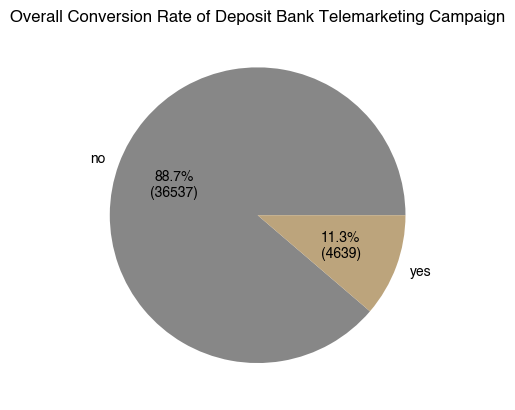

In [27]:
counts = x = df_bank_biv['y'].value_counts()
labels = counts.index.tolist()
sizes = counts.values.tolist()
total = sum(sizes)

def autopct_format(pct):
        absolute_count = int(pct/100.*total)
        return f"{pct:.1f}%\n({absolute_count})"

plt.pie(
    x = sizes,
    labels = labels,
    autopct=autopct_format,
    colors= ['#878787','#bca47c']
)
plt.title ('Overall Conversion Rate of Deposit Bank Telemarketing Campaign')
plt.show()

The pie chart shows that the deposit campaign had a low conversion rate of just 11.3%. This result suggests that the telemarketing efforts may not have been conducted strategically.

### 2.5.2 Duration

In [28]:
df_bank_biv['duration_in_minute'] = (df_bank_biv['duration']/60).round(2)
print(df_bank_biv['duration_in_minute'])

0        4.35
1        2.48
2        3.77
3        2.52
4        5.12
         ... 
41183    5.57
41184    6.38
41185    3.15
41186    7.37
41187    3.98
Name: duration_in_minute, Length: 41176, dtype: float64


--- Statistical Analysis (Mann-Whitney U Test) ---

- duration:
  U-statistic: 138721931.0000
  p-value: 0.0000
  Conclusion: There is a statistically significant difference in the medians of the two groups.


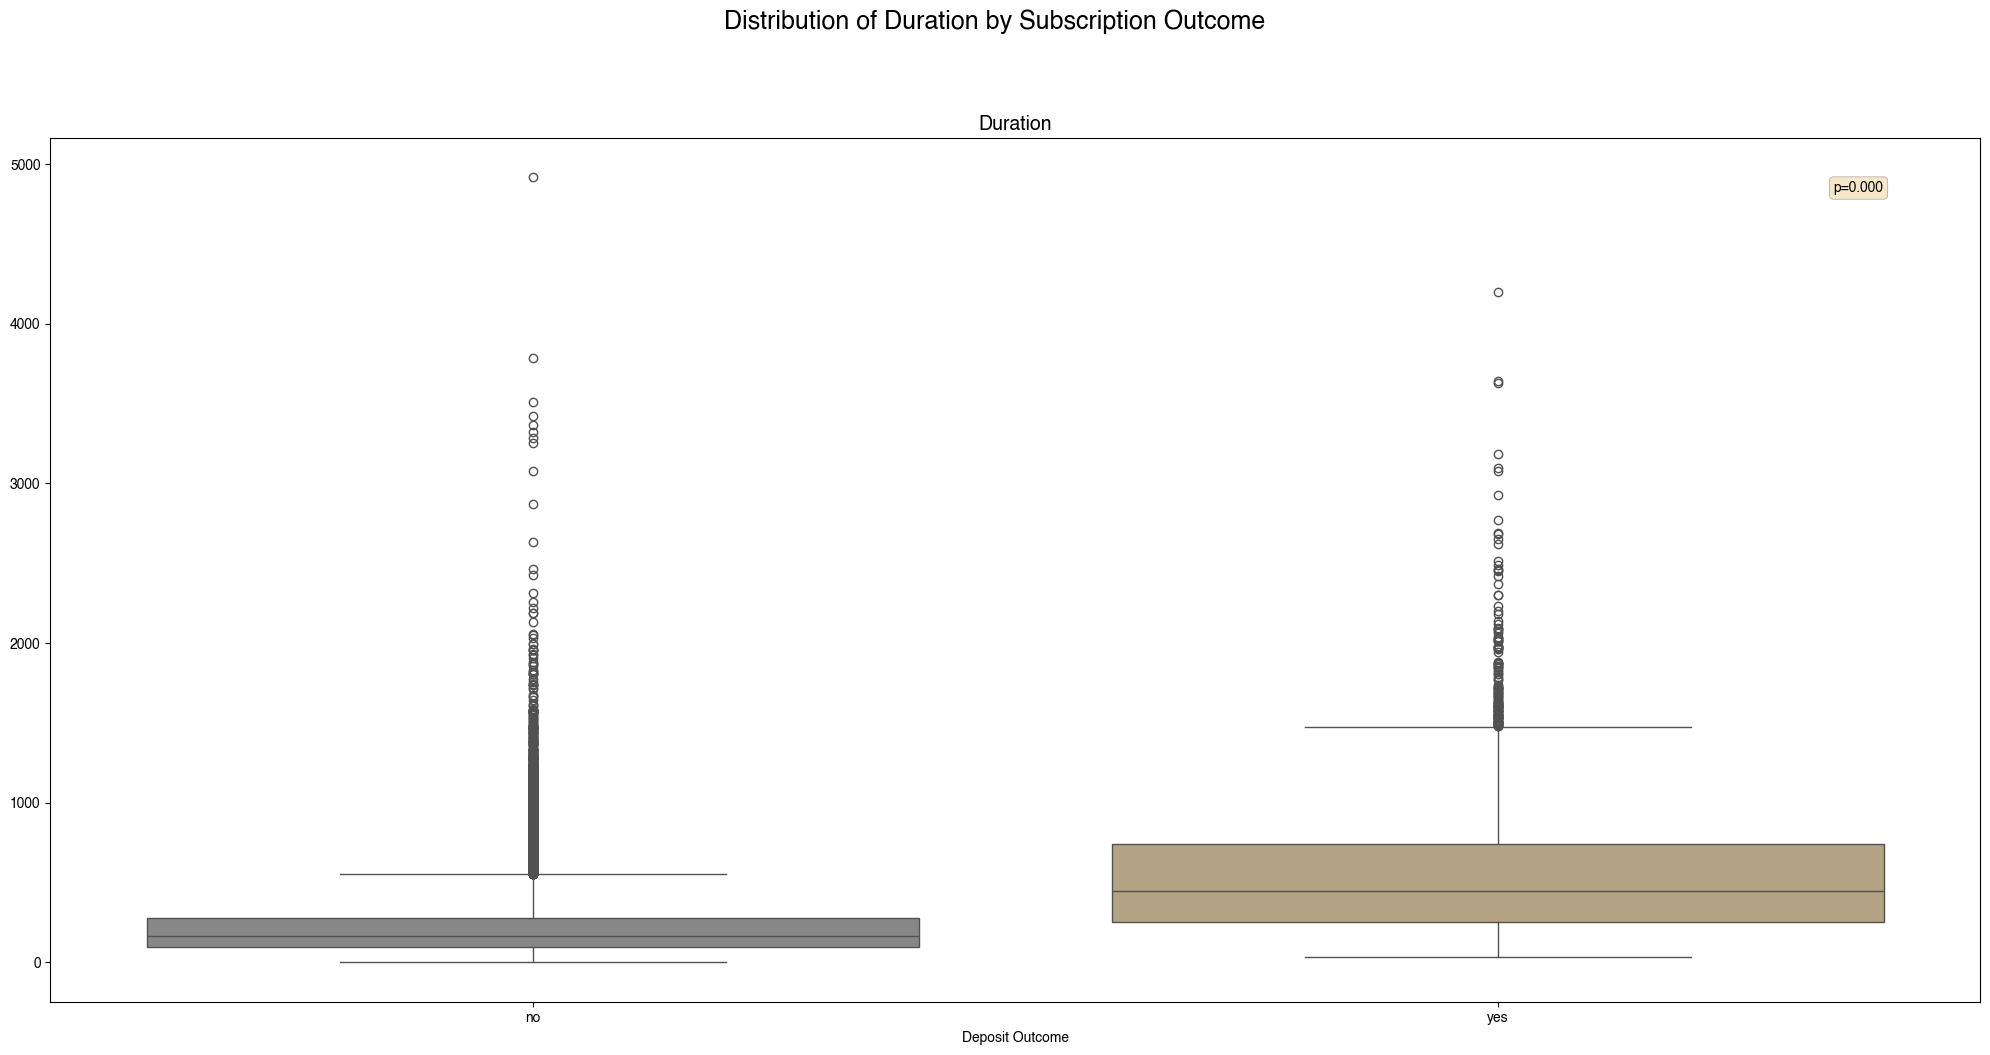

In [29]:
indicators = ['duration']

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(20, 10), sharey=False)
colors = ['#878787','#bca47c']

print("--- Statistical Analysis (Mann-Whitney U Test) ---")

for i, indicator in enumerate(indicators):
    yes_group = df_bank_biv[df_bank_biv['y'] == 'yes'][indicator]
    no_group = df_bank_biv[df_bank_biv['y'] == 'no'][indicator]

    u_statistic, p_value = stats.mannwhitneyu(yes_group, no_group, alternative='two-sided')
    
    print(f"\n- {indicator}:")
    print(f"  U-statistic: {u_statistic:.4f}")
    print(f"  p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("  Conclusion: There is a statistically significant difference in the medians of the two groups.")
    else:
        print("  Conclusion: There is no statistically significant difference in the medians of the two groups.")

    sns.boxplot(
        x='y',
        y=indicator,
        data=df_bank_biv,
        palette=colors,
    )
    
    axes.set_title(indicator.replace('_', ' ').title(), fontsize=14)
    axes.set_xlabel('Deposit Outcome')
    axes.set_ylabel('')
    
    axes.text(0.95, 0.95, f'p={p_value:.3f}', transform=axes.transAxes,
                 fontsize=10, ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', ec='gray', lw=0.5, alpha=0.7))

fig.suptitle('Distribution of Duration by Subscription Outcome', fontsize=18, y=1.05)
plt.tight_layout()

In [30]:
median_minute = df_bank_biv['duration_in_minute'].median()
print(f"Median of duration in minute of overall calls : {median_minute:.2f}")

yes = df_bank_biv[df_bank_biv['y'] == 'yes']
no = df_bank_biv[df_bank_biv['y'] == 'no']
median_minute_yes = yes['duration_in_minute'].median()
median_minute_no = no['duration_in_minute'].median()

print(
    f"Median of duration in minute for customer subscribing deposito : {median_minute_yes:.2f}\n"
    f"Median of duration in minute for customer not subscribing deposito :{median_minute_no:.2f}"
    )

Median of duration in minute of overall calls : 3.00


Median of duration in minute for customer subscribing deposito : 7.48
Median of duration in minute for customer not subscribing deposito :2.73


In [31]:
median_campaign = df_bank_biv['campaign'].median()
print(f"Median of number of calls : {median_campaign:.2f}")

yes = df_bank_biv[df_bank_biv['y'] == 'yes']
no = df_bank_biv[df_bank_biv['y'] == 'no']
median_calls_yes = yes['campaign'].median()
median_calls_no = no['campaign'].median()

print(
    f"Median of number of calls of campaign for customer subscribing deposito : {median_calls_yes:.2f}\n"
    f"Median of number of calls of campaign for customer not subscribing deposito :{median_calls_no:.2f}"
    )

Median of number of calls : 2.00
Median of number of calls of campaign for customer subscribing deposito : 2.00
Median of number of calls of campaign for customer not subscribing deposito :2.00


In [32]:
df_bank_biv.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.conf.idx,euribor3m,nr.employed,y,age_group,campaign_calls,previous_campaign_calls,education_group,pdays_group,duration_in_minute
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,-36.4,4.857,5191.0,no,55-64,1 Calls,0 Calls,Primary Education,Not Previously Contacted,4.35
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,-36.4,4.857,5191.0,no,55-64,1 Calls,0 Calls,High Education,Not Previously Contacted,2.48
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,-36.4,4.857,5191.0,no,35-44,1 Calls,0 Calls,High Education,Not Previously Contacted,3.77
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,-36.4,4.857,5191.0,no,35-44,1 Calls,0 Calls,Primary Education,Not Previously Contacted,2.52
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,-36.4,4.857,5191.0,no,55-64,1 Calls,0 Calls,High Education,Not Previously Contacted,5.12


### 2.5.3 Deposit Subscribtion Based on Age Group

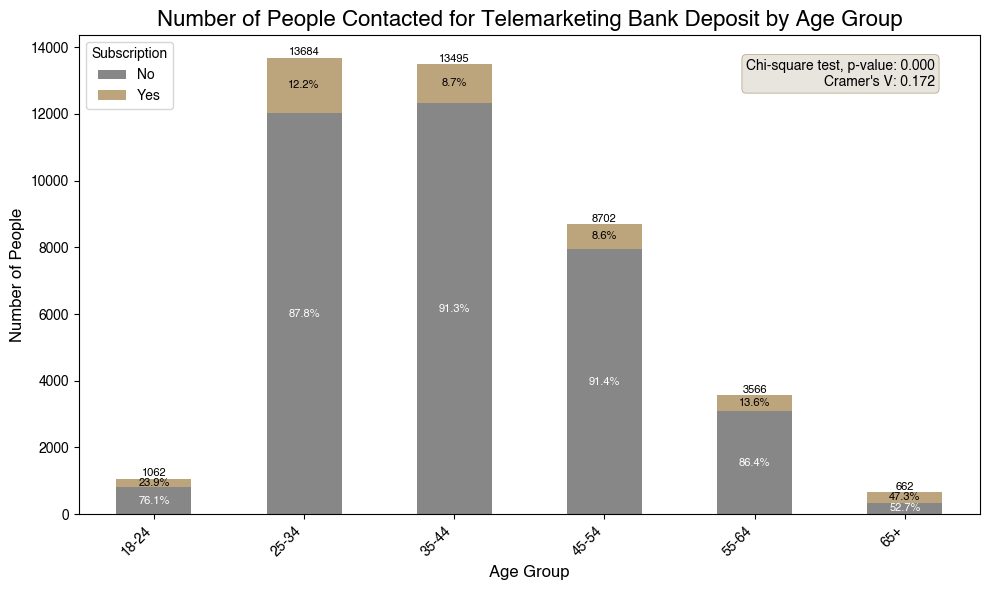

In [33]:
cross_tab_age = pd.crosstab(df_bank_biv['age_group'], df_bank_biv['y'])

conversion_counts = cross_tab_age.copy()
ordered_age_groups = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
conversion_counts = conversion_counts.reindex(ordered_age_groups)

conversion_counts.columns = conversion_counts.columns.str.lower()

colors = ['#878787','#bca47c']

ax = conversion_counts.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(conversion_counts.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(conversion_counts.index):
    total = conversion_counts.loc[group].sum()
    yes_count = conversion_counts.loc[group]['yes']
    no_count = conversion_counts.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_age)
n = cross_tab_age.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_age.shape
cramer_v_age = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_age:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

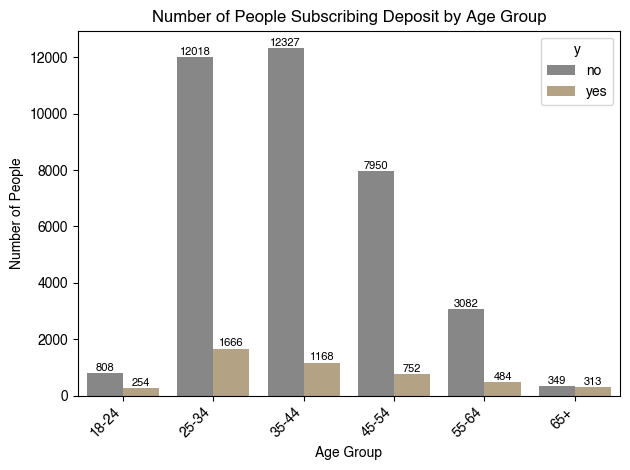

In [34]:
df_bank_biv = df_bank_biv[df_bank_biv['age_group'] != 'Under 18']

ordered_age_groups = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

df_bank_biv['age_group'] = pd.Categorical(df_bank_biv['age_group'], categories=ordered_age_groups, ordered=True)

sns.countplot(df_bank_biv, x='age_group', hue="y", palette=['#878787','#bca47c'])

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0: 
        ax.text(p.get_x() + p.get_width() / 2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of People Subscribing Deposit by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
age_group_summary = df_bank_biv.groupby('age_group')['y'].value_counts().unstack().fillna(0)
age_group_summary['Total People Called'] = age_group_summary['yes'] + age_group_summary['no']

total_dataset_people = len(df_bank_biv)
age_group_summary['Age Group Proportion %'] = (age_group_summary['Total People Called'] / total_dataset_people * 100).round(2)

age_group_summary['Conversion Rate %'] = (age_group_summary['yes'] / age_group_summary['Total People Called'] * 100).round(2)

result = age_group_summary[['Total People Called', 'Age Group Proportion %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

ordered_age_groups = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

result = result.reindex(ordered_age_groups)

print(result)

y          Total People Called  Age Group Proportion %  People Who Accepted  \
age_group                                                                     
18-24                     1062                    2.58                  254   
25-34                    13684                   33.24                 1666   
35-44                    13495                   32.78                 1168   
45-54                     8702                   21.14                  752   
55-64                     3566                    8.66                  484   
65+                        662                    1.61                  313   

y          Conversion Rate %  
age_group                     
18-24                  23.92  
25-34                  12.17  
35-44                   8.66  
45-54                   8.64  
55-64                  13.57  
65+                    47.28  


In [36]:
pd.crosstab(df_bank_biv['age_group'],df_bank_biv['y'],normalize=0)

y,no,yes
age_group,,
18-24,0.760829,0.239171
25-34,0.878252,0.121748
35-44,0.913449,0.086551
45-54,0.913583,0.086417
55-64,0.864274,0.135726
65+,0.527190,0.472810


In [37]:
df_bank_biv.query('age_group=="65+"')

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.conf.idx,euribor3m,nr.employed,y,age_group,campaign_calls,previous_campaign_calls,education_group,pdays_group,duration_in_minute
27713,70,retired,divorced,basic.4y,no,yes,no,cellular,mar,mon,...,-50.0,1.811,5099.1,yes,65+,3 Calls,0 Calls,Primary Education,Not Previously Contacted,3.12
27723,66,technician,married,professional.course,no,yes,no,cellular,mar,tue,...,-50.0,1.799,5099.1,yes,65+,1 Calls,0 Calls,High Education,Not Previously Contacted,1.38
27757,76,retired,married,university.degree,no,no,yes,cellular,mar,thu,...,-50.0,1.757,5099.1,no,65+,More than 5 calls,0 Calls,Higher Education,Not Previously Contacted,2.78
27774,67,retired,single,university.degree,no,yes,yes,cellular,mar,mon,...,-50.0,1.703,5099.1,no,65+,More than 5 calls,0 Calls,Higher Education,Not Previously Contacted,1.17
27780,73,retired,married,university.degree,no,yes,no,cellular,mar,tue,...,-50.0,1.687,5099.1,no,65+,1 Calls,1 Calls,Higher Education,Not Previously Contacted,2.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41052,65,retired,married,basic.4y,no,no,no,cellular,oct,wed,...,-49.5,1.043,4963.6,yes,65+,1 Calls,0 Calls,Primary Education,Not Previously Contacted,14.70
41058,65,retired,married,basic.4y,no,yes,no,cellular,oct,wed,...,-49.5,1.043,4963.6,yes,65+,1 Calls,3 Calls,Primary Education,Recently Contacted,4.30
41153,67,housemaid,divorced,professional.course,no,yes,no,cellular,nov,mon,...,-50.8,1.039,4963.6,yes,65+,2 Calls,5 Calls,High Education,Recently Contacted,10.92
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,-50.8,1.028,4963.6,yes,65+,1 Calls,0 Calls,High Education,Not Previously Contacted,5.57


In [38]:
filtered_df = df_bank_biv[df_bank_biv['age_group'].isin(['65+', '25-34'])]

cross_tab = pd.crosstab([filtered_df['education_group'], filtered_df['job']], filtered_df['age_group'])

print(cross_tab)

age_group                        25-34  65+
education_group   job                      
High Education    admin.          1414    0
                  blue-collar      514    1
                  entrepreneur     100    3
                  housemaid         69    3
                  management        83    2
                  retired            4  120
                  self-employed     83    1
                  services        1162    0
                  student          196    0
                  technician      1509    5
                  unemployed       134    0
                  unknown           14    0
Higher Education  admin.          2627    9
                  blue-collar       47    0
                  entrepreneur     139    1
                  housemaid         38    0
                  management       538    5
                  retired            0   81
                  self-employed    325    2
                  services          99    0
                  student       

#### Statistical Findings

Based on the chi-square test, there's a statistically significant relationship between a customer's age and their decision to participate in a bank deposit program. This means that age is a key factor in determining customer behavior for this campaign.

##### Age Group Analysis

An analysis of the bar chart and age group conversion rates reveals a striking pattern. The age groups with the most telemarketing calls, 25-34 and 35-44, had some of the lowest conversion rates.

In contrast, customers aged 65 and older had the highest conversion rate at 47.28%, despite receiving a relatively small number of calls. The group under 18 was excluded from the analysis due to their negligible contribution (only 0.01% of the total data). In addition, the similar trend can be shown in 18 - 24 group, when it's proportion only contribute 2.58% to overall sample, it's conversion rate could be considered as high among the other, 23.89%.


##### Strategic Recommendation

Tambahin untuk group 18-24 age group

Although the 65+ age group represents a smaller population segment, their high conversion rate presents a significant opportunity. This may be because many individuals in this age group are retired and are seeking savings or investment options that can generate a stable income. Data from the World Bank's collection of development indicators indicates that the proportion of the 65+ age group could be approximately 24% of the total population. There is possibility for marketing bank to reach out more elderly people for applying deposit. 

Potential reaching out new leads can be explored for the people age-group 18-24 as this group is stepping up to the next stage of life with less financial burden compare to other 'productive' age group. This make them as a potential customer leads for deposit program.

Despite these groups's potential, they only account for less than 2.5% (each of category)of the total customers acquired through current telemarketing efforts. It is therefore recommended that the telemarketing team increase its outreach to this demographic in the future. By focusing more effort on 18-24 age group and elderly populaion, the bank-deposit campaign is expected to achieve a higher overall success rate, as these groups are more likely to convert than other counterparts. 


### 2.5.4 Deposit Subscribtion based on Marital Status

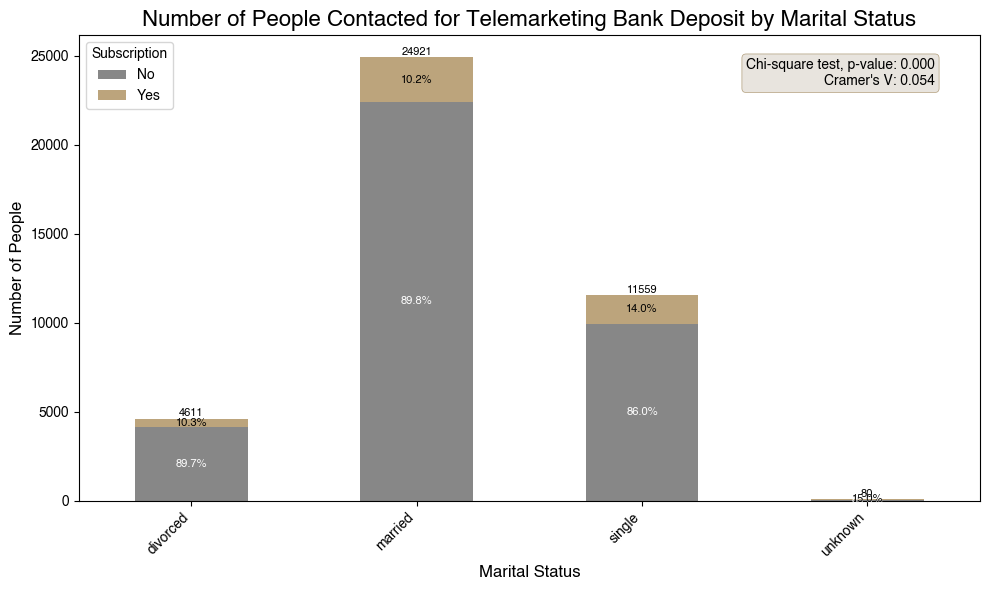

In [39]:
cross_tab_marital = pd.crosstab(df_bank_biv['marital'], df_bank_biv['y'])

cross_tab_marital.columns = cross_tab_marital.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_marital.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Marital Status', fontsize=16)
plt.xlabel('Marital Status', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_marital.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_marital.index):
    total = cross_tab_marital.loc[group].sum()
    yes_count = cross_tab_marital.loc[group]['yes']
    no_count = cross_tab_marital.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_marital)
n = cross_tab_marital.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_marital.shape
cramer_v_marital = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_marital:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

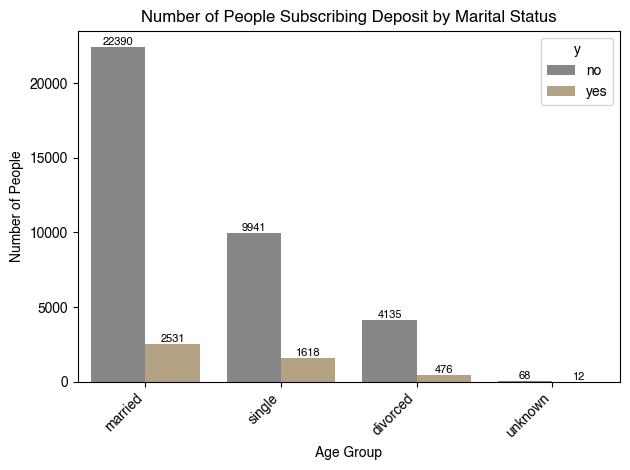

In [40]:
sns.countplot(df_bank_biv, x='marital', hue="y", palette=['#878787','#bca47c'])

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of People Subscribing Deposit by Marital Status')
plt.xlabel('Age Group')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [41]:
marital_status_summary = df_bank_biv.groupby('marital')['y'].value_counts().unstack().fillna(0)
marital_status_summary['Total People Called'] = marital_status_summary['yes'] + marital_status_summary['no']

total_dataset_people = len(df_bank_biv)
marital_status_summary['Marital Status Proportion %'] = (marital_status_summary['Total People Called'] / total_dataset_people * 100).round(2)

marital_status_summary['Conversion Rate %'] = (marital_status_summary['yes'] / marital_status_summary['Total People Called'] * 100).round(2)

result = marital_status_summary[['Total People Called', 'Marital Status Proportion %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

result = result.sort_values(by='Conversion Rate %', ascending=False)
print(result)

y         Total People Called  Marital Status Proportion %  \
marital                                                      
unknown                    80                         0.19   
single                  11559                        28.08   
divorced                 4611                        11.20   
married                 24921                        60.53   

y         People Who Accepted  Conversion Rate %  
marital                                           
unknown                    12              15.00  
single                   1618              14.00  
divorced                  476              10.32  
married                  2531              10.16  


In [42]:
filtered_df = df_bank_biv[df_bank_biv['marital'] == 'single']

cross_tab = pd.crosstab(filtered_df['education_group'], filtered_df['y'],normalize=0)

print(cross_tab)

y                        no       yes
education_group                      
High Education     0.863268  0.136732
Higher Education   0.844949  0.155051
Illiterate         1.000000  0.000000
Primary Education  0.901094  0.098906
unknown            0.787056  0.212944


In [43]:
filtered_df = df_bank_biv[df_bank_biv['marital'] == 'single']

cross_tab = pd.crosstab(filtered_df['age_group'], filtered_df['y'],normalize=0)

print(cross_tab)

y                no       yes
age_group                    
18-24      0.738378  0.261622
25-34      0.852169  0.147831
35-44      0.904778  0.095222
45-54      0.900266  0.099734
55-64      0.893855  0.106145
65+        0.615385  0.384615


#### Statistical Findings

Based on the chi-square test, there's a statistically significant relationship between a customer's marital status and their decision to participate in a bank deposit program. This means that marital status is a key factor in determining customer behavior for this campaign.

##### Marital Status Analysis

An analysis of the bar chart and conversion rates by marital status reveals a statistically significant difference in conversion rates among the groups. However, the conversion rate itself is relatively low across all groups, with only a small difference between them. 

Single customers had the highest conversion rate at 14.00%. This is particularly noteworthy as they received only two-thirds the number of calls directed at the married group. If we breakdown more, there were several groups that have higher conversion rate with 'single' status, those are single-student, single-18-24 age group, and single 65+ age group. 

The "unknown" marital status group was excluded from the analysis because their contribution was negligible (only 0.19% of the total data) and it is possible that unknown data is part of other categories .

##### Strategic Recommendation

Although the single demographic is smaller in size compared to the married demographic, its high conversion rate suggests a significant opportunity. Telemarketing efforts should prioritize reaching out to single individuals who are students, aged 18-24, or over 65. These groups likely have fewer dependents or financial burdens, making them more inclined to apply for a deposit. By targeting telemarketing efforts toward this group, the overall success of the bank-deposit campaign could be improved.

### 2.5.5 Deposit Subscribtion based on Education

#### 2.5.5.2 With Grouping

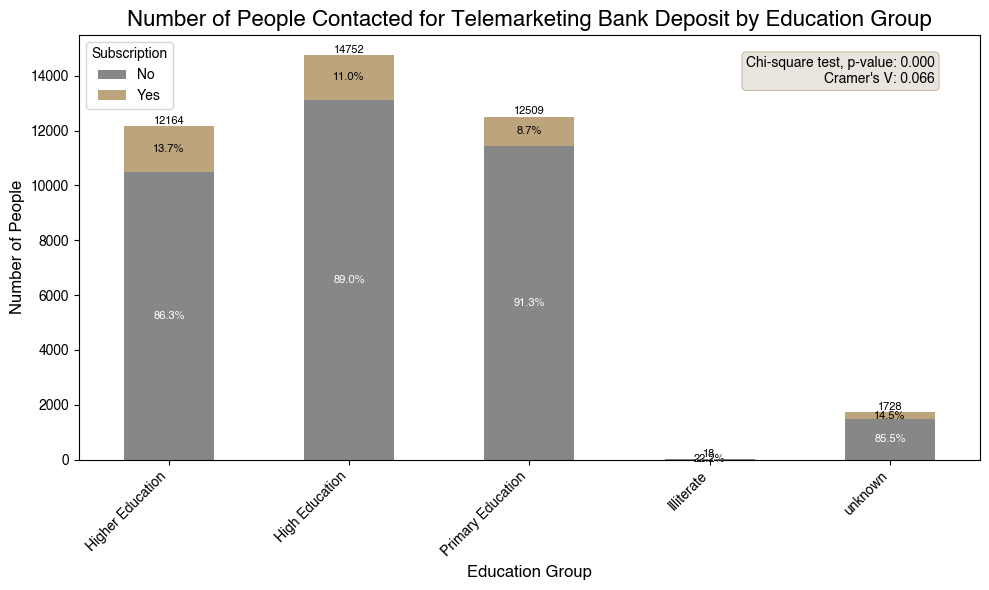

In [44]:
custom_order = ['Higher Education', 'High Education', 'Primary Education', 'Illiterate', 'unknown']

cross_tab_education_group = pd.crosstab(df_bank_biv['education_group'], df_bank_biv['y'])

cross_tab_education_group = cross_tab_education_group.reindex(custom_order)

cross_tab_education_group.columns = cross_tab_education_group.columns.str.lower()

colors = ['#878787','#bca47c']
ax = cross_tab_education_group.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Education Group', fontsize=16)
plt.xlabel('Education Group', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_education_group.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_education_group.index):
    total = cross_tab_education_group.loc[group].sum()
    yes_count = cross_tab_education_group.loc[group]['yes']
    no_count = cross_tab_education_group.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_education_group.dropna(how='all'))
n = cross_tab_education_group.dropna(how='all').sum().sum()
phi2 = chi2 / n
r, k = cross_tab_education_group.dropna(how='all').shape
cramer_v_education_group = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_education_group:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

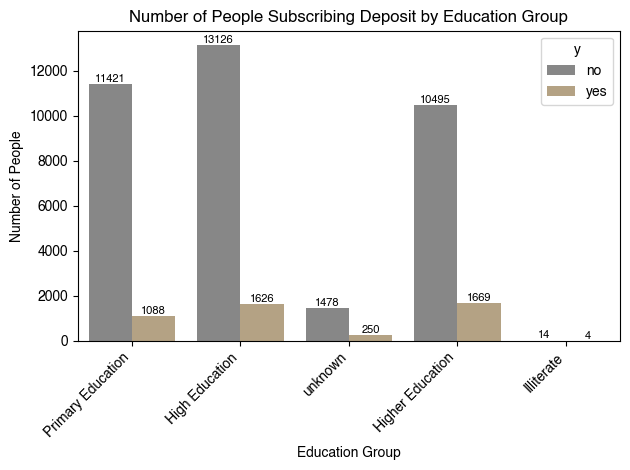

In [45]:
sns.countplot(df_bank_biv, x='education_group', hue="y", palette=['#878787','#bca47c'])

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of People Subscribing Deposit by Education Group')
plt.xlabel('Education Group')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [46]:
filtered_df = df_bank_biv[df_bank_biv['marital'] == 'single']
df_bank_biv_cek = df_bank_biv[df_bank_biv['y']== 'yes']
df_bank_biv_cek.query('education_group == "Illiterate"')

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.conf.idx,euribor3m,nr.employed,y,age_group,campaign_calls,previous_campaign_calls,education_group,pdays_group,duration_in_minute
26689,34,self-employed,married,illiterate,no,yes,no,cellular,nov,thu,...,-42.0,4.076,5195.8,yes,25-34,1 Calls,0 Calls,Illiterate,Not Previously Contacted,8.13
28627,51,entrepreneur,married,illiterate,no,yes,no,cellular,apr,thu,...,-47.1,1.410,5099.1,yes,45-54,3 Calls,0 Calls,Illiterate,Not Previously Contacted,13.97
37355,80,retired,married,illiterate,unknown,yes,yes,cellular,aug,tue,...,-31.4,0.883,5076.2,yes,65+,1 Calls,1 Calls,Illiterate,Recently Contacted,2.08
37813,42,retired,divorced,illiterate,no,no,no,telephone,aug,wed,...,-31.4,0.834,5076.2,yes,35-44,3 Calls,0 Calls,Illiterate,Not Previously Contacted,2.13


In [47]:
educationgroup_summary = df_bank_biv.groupby('education_group')['y'].value_counts().unstack().fillna(0)
educationgroup_summary['Total People Called'] = educationgroup_summary['yes'] + educationgroup_summary['no']

total_dataset_people = len(df_bank_biv)
educationgroup_summary['Education Group Proportion %'] = (educationgroup_summary['Total People Called'] / total_dataset_people * 100).round(2)

educationgroup_summary['Conversion Rate %'] = (educationgroup_summary['yes'] /educationgroup_summary['Total People Called'] * 100).round(2)

result = educationgroup_summary[['Total People Called', 'Education Group Proportion %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

result = result.sort_values(by='Conversion Rate %', ascending=False)
print(result)

y                  Total People Called  Education Group Proportion %  \
education_group                                                        
Illiterate                          18                          0.04   
unknown                           1728                          4.20   
Higher Education                 12164                         29.55   
High Education                   14752                         35.83   
Primary Education                12509                         30.38   

y                  People Who Accepted  Conversion Rate %  
education_group                                            
Illiterate                           4              22.22  
unknown                            250              14.47  
Higher Education                  1669              13.72  
High Education                    1626              11.02  
Primary Education                 1088               8.70  


#### Statistical Findings

Based on the chi-square test, there's a statistically significant relationship between a customer's education and their decision to participate in a bank deposit program even it's correlation quite low. 

##### Education Group Analysis

An analysis of the bar chart and conversion rates by education reveals a noticeable pattern. The Illiterate and Unknown groups both have significantly higher conversion rates compared to the other groups. However, these need to be caution due to the small percentage of these groups (0.04% and 4.20%, respectively). Other than that, unknown group might be part of other age group category.

A linear correlation can be observed among the remaining groups (higher, high, and primary education): the higher a person's education level, the higher their conversion rate. Even though fewer people with higher education were contacted compared to those with a high school background, their conversion rate remained higher and was, in fact, the highest at 13.7%. This suggests a clear trend: reaching more people with higher education will likely increase the overall conversion rate.

##### Strategic Recommendation

To improve future campaigns, it is recommended that the company focus on three key areas:

1. Identify the "Unknown" Group: The high conversion rate of the unknown group presents a significant opportunity. To better understand this segment, efforts should be made to collect their educational background in future campaigns. It is probable that this group is a part of another education demographic.

2. Explore the "Illiterate" Group: Given their high conversion rate, the illiterate demographic should be explored as a potential target for specialized campaigns. However, this segment needs further exploration, as it only accounted for 0.04% of all contacted customers in this telemarketing program. 

3. Focus on Higher Education: While refining the above aspects, the next telemarketing campaign should continue to prioritize individuals with higher education backgrounds. It is assumed that this group is more aware of the benefits of a deposit program, making them a consistently valuable segment to target.

### 2.5.6 Deposit Subscribtion based on Job

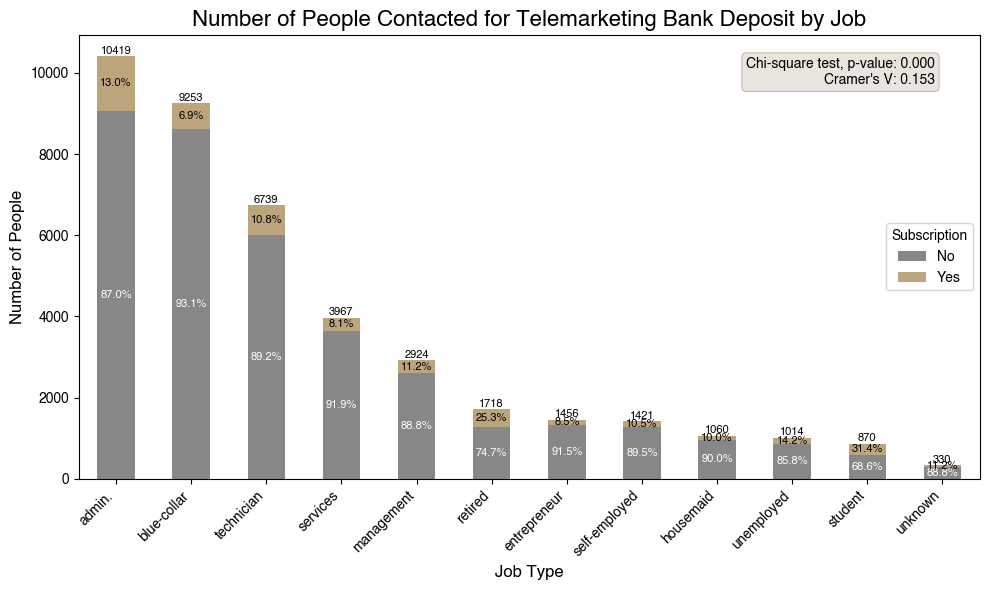

In [48]:
cross_tab_job = pd.crosstab(df_bank_biv['job'], df_bank_biv['y'])

cross_tab_job = cross_tab_job.reindex(cross_tab_job.sum(axis=1).sort_values(ascending=False).index)

cross_tab_job.columns = cross_tab_job.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_job.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Job', fontsize=16)
plt.xlabel('Job Type', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_job.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_job.index):
    total = cross_tab_job.loc[group].sum()
    yes_count = cross_tab_job.loc[group]['yes']
    no_count = cross_tab_job.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_job)
n = cross_tab_job.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_job.shape
cramer_v_job = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_job:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

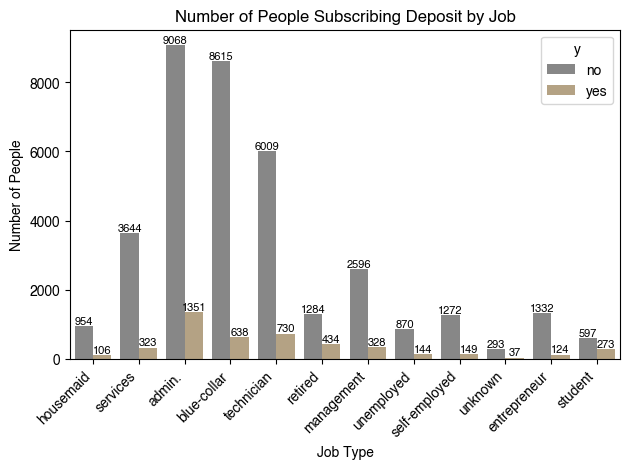

In [49]:
sns.countplot(df_bank_biv, x='job', hue="y", palette=['#878787','#bca47c'])

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of People Subscribing Deposit by Job')
plt.xlabel('Job Type')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [50]:
job_summary = df_bank_biv.groupby('job')['y'].value_counts().unstack().fillna(0)
job_summary['Total People Called'] = job_summary['yes'] + job_summary['no']

total_dataset_people = len(df_bank_biv)
job_summary['Job Proportion %'] = (job_summary['Total People Called'] / total_dataset_people * 100).round(2)

job_summary['Conversion Rate %'] = (job_summary['yes'] / job_summary['Total People Called'] * 100).round(2)

result = job_summary[['Total People Called', 'Job Proportion %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

result = result.sort_values(by='Conversion Rate %', ascending=False)
print(result)

y              Total People Called  Job Proportion %  People Who Accepted  \
job                                                                         
student                        870              2.11                  273   
retired                       1718              4.17                  434   
unemployed                    1014              2.46                  144   
admin.                       10419             25.31                 1351   
management                    2924              7.10                  328   
unknown                        330              0.80                   37   
technician                    6739             16.37                  730   
self-employed                 1421              3.45                  149   
housemaid                     1060              2.57                  106   
entrepreneur                  1456              3.54                  124   
services                      3967              9.64                  323   

In [51]:
df_bank_biv_cek.query('job == "admin."')

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.conf.idx,euribor3m,nr.employed,y,age_group,campaign_calls,previous_campaign_calls,education_group,pdays_group,duration_in_minute
820,31,admin.,single,university.degree,no,no,no,telephone,may,wed,...,-36.4,4.856,5191.0,yes,25-34,1 Calls,0 Calls,Higher Education,Not Previously Contacted,16.53
1114,54,admin.,divorced,university.degree,no,no,no,telephone,may,wed,...,-36.4,4.856,5191.0,yes,45-54,4 Calls,0 Calls,Higher Education,Not Previously Contacted,28.15
1319,54,admin.,married,university.degree,no,no,no,telephone,may,thu,...,-36.4,4.855,5191.0,yes,45-54,1 Calls,0 Calls,Higher Education,Not Previously Contacted,8.55
1791,32,admin.,married,university.degree,no,no,yes,telephone,may,fri,...,-36.4,4.855,5191.0,yes,25-34,2 Calls,0 Calls,Higher Education,Not Previously Contacted,28.20
1809,43,admin.,married,university.degree,unknown,yes,no,telephone,may,fri,...,-36.4,4.855,5191.0,yes,35-44,2 Calls,0 Calls,Higher Education,Not Previously Contacted,33.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41160,33,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,-50.8,1.035,4963.6,yes,25-34,1 Calls,0 Calls,Higher Education,Not Previously Contacted,14.05
41164,54,admin.,married,professional.course,no,no,no,cellular,nov,tue,...,-50.8,1.035,4963.6,yes,45-54,2 Calls,1 Calls,High Education,Recently Contacted,31.13
41166,32,admin.,married,university.degree,no,no,no,telephone,nov,wed,...,-50.8,1.030,4963.6,yes,25-34,1 Calls,1 Calls,Higher Education,Not Previously Contacted,10.85
41172,31,admin.,single,university.degree,no,yes,no,cellular,nov,thu,...,-50.8,1.031,4963.6,yes,25-34,1 Calls,0 Calls,Higher Education,Not Previously Contacted,5.88


In [52]:
target_group = df_bank_biv[
    (df_bank_biv['y'] == 'no')&
    (df_bank_biv['job'] == 'admin.')
]

most_likely_marital = target_group['marital'].mode()

marital_counts = target_group['marital'].value_counts()

print(f"The most likely marital for admin who subscribed is: {most_likely_marital}")
print("\nBreakdown of marital within this group:")
print(marital_counts)

The most likely marital for admin who subscribed is: 0    married
Name: marital, dtype: object

Breakdown of marital within this group:
marital
married     4599
single      3309
divorced    1148
unknown       12
Name: count, dtype: int64


In [53]:
target_group = df_bank_biv[
    (df_bank_biv['y'] == 'yes')&
    (df_bank_biv['job'] == 'student')
]

most_likely_marital = target_group['month'].mode()

marital_counts = target_group['month'].value_counts()

print(f"The most likely marital for student who subscribed is: {most_likely_marital}")
print("\nBreakdown of marital within this group:")
print(marital_counts)

The most likely marital for student who subscribed is: 0    aug
1    may
Name: month, dtype: object

Breakdown of marital within this group:
month
may    43
aug    43
apr    35
jun    33
oct    26
mar    25
jul    22
sep    22
nov    18
dec     6
Name: count, dtype: int64


#### Statistical Findings

Based on the chi-square test, there's a statistically significant relationship between a customer's job and their decision to participate in a bank deposit program. This means that job is a key factor in determining customer behavior for this campaign.

##### Job Group Analysis

An analysis of the bar chart and job category conversion rates reveals an interesting finding. The conversion rate for students is the highest among all groups, yet they represent a small portion of the overall sample, accounting for only 2.11% of the people contacted.

Similarly, the retired group has the second-highest conversion rate, even though their aggregate number is significantly smaller than the three largest job categories: admin, blue-collar, and technician.

Conversely, the blue-collar group—the second-largest group in the campaign—has the lowest conversion rate. The admin group, which is the largest, shows an acceptable conversion rate, indicating a more favorable balance between volume and conversion success.

##### Strategic Recommendation

To increase potential customer leads, telemarketing teams should consider reaching out to more students and retired individuals. Even though these groups currently represent a small portion of the contacts, their high conversion rates offer a good opportunity to boost the overall conversion percentage.

If resources are limited, the blue-collar segment should be given a lower priority. This allows the team to focus on higher-converting groups, a strategy that improves efficiency by directing resources toward segments most likely to yield a positive return on investment.

### 2.5.7 Deposit Subscribtion based on Having Credit in Default

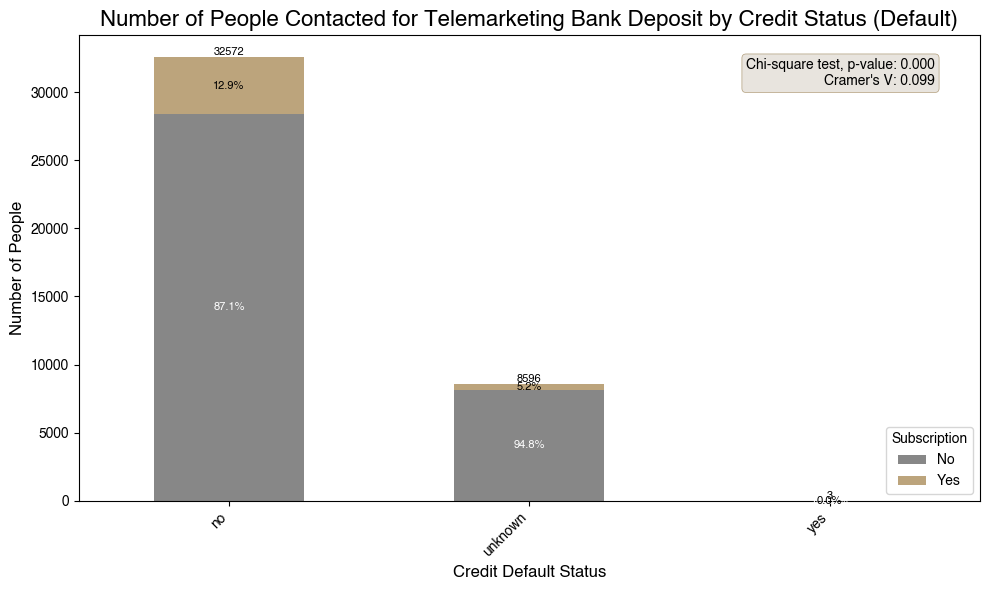

In [54]:
cross_tab_default = pd.crosstab(df_bank_biv['default'], df_bank_biv['y'])

cross_tab_default = cross_tab_default.reindex(cross_tab_default.sum(axis=1).sort_values(ascending=False).index)

cross_tab_default.columns = cross_tab_default.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_default.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Credit Status (Default)', fontsize=16)
plt.xlabel('Credit Default Status', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_default.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_default.index):
    total = cross_tab_default.loc[group].sum()
    yes_count = cross_tab_default.loc[group]['yes']
    no_count = cross_tab_default.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_default)
n = cross_tab_default.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_default.shape
cramer_v_default = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_default:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

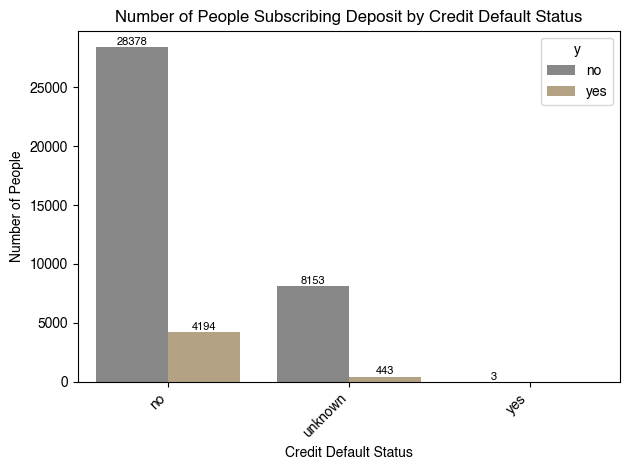

In [55]:
sns.countplot(df_bank_biv, x='default', hue="y", palette=['#878787','#bca47c'])

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of People Subscribing Deposit by Credit Default Status')
plt.xlabel('Credit Default Status')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [56]:
default_summary = df_bank_biv.groupby('default')['y'].value_counts().unstack().fillna(0)
default_summary['Total People Called'] = default_summary['yes'] + default_summary['no']

total_dataset_people = len(df_bank_biv)
default_summary['Default Proportion %'] = (default_summary['Total People Called'] / total_dataset_people * 100).round(2)

default_summary['Conversion Rate %'] = (default_summary['yes'] / default_summary['Total People Called'] * 100).round(2)

result = default_summary[['Total People Called', 'Default Proportion %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

result = result.sort_values(by='Conversion Rate %', ascending=False)
print(result)

y        Total People Called  Default Proportion %  People Who Accepted  \
default                                                                   
no                   32572.0                 79.11               4194.0   
unknown               8596.0                 20.88                443.0   
yes                      3.0                  0.01                  0.0   

y        Conversion Rate %  
default                     
no                   12.88  
unknown               5.15  
yes                   0.00  


#### Statistical Findings

Based on the chi-square test, there's a statistically significant relationship between a credit default and their decision to participate in a bank deposit program. This means that default is a key factor in determining customer behavior for this campaign.

##### Credit Default Analysis

Based on the graph and conversion rate table, the majority of people contacted in the telemarketing campaign do not have a credit default. This group accounts for 79.11% of the sample and has a conversion rate of 12.88%. The unknown status group makes up 20.88% of the sample, with a conversion rate of 5.15%. Meanwhile, the group with a credit default constitutes only 0.01% of the sample and has a 0% success rate.


##### Strategic Recommendation

Based on the statistical test, which is clearly supported by the graph and conversion rates, the telemarketing team should highly prioritize the group without a credit default. 

### 2.5.8 Deposit Subscribtion based on Housing Loan

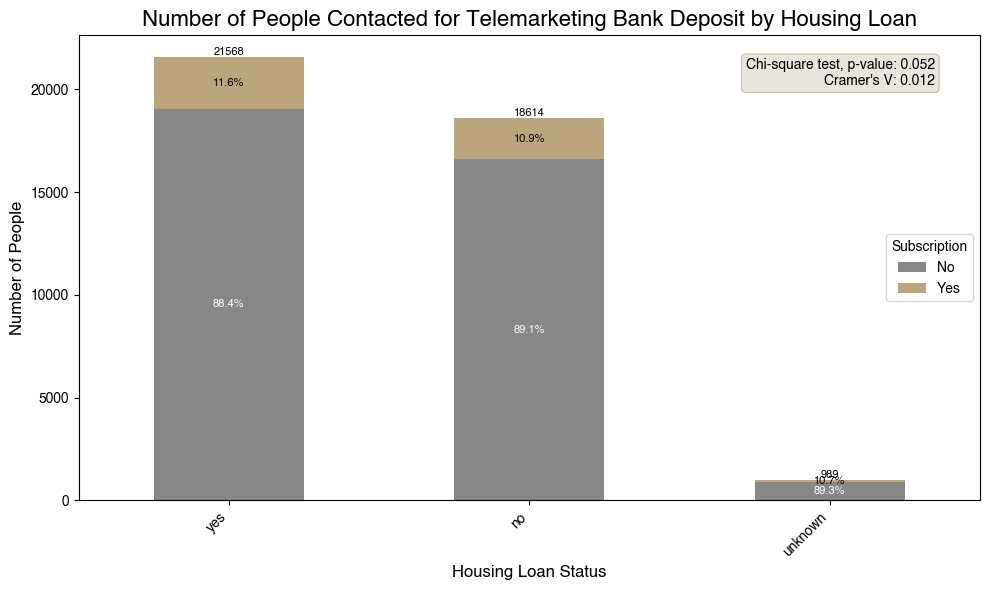

In [57]:
cross_tab_housing = pd.crosstab(df_bank_biv['housing'], df_bank_biv['y'])

cross_tab_housing = cross_tab_housing.reindex(cross_tab_housing.sum(axis=1).sort_values(ascending=False).index)

cross_tab_housing.columns = cross_tab_housing.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_housing.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Housing Loan', fontsize=16)
plt.xlabel('Housing Loan Status', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_housing.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_housing.index):
    total = cross_tab_housing.loc[group].sum()
    yes_count = cross_tab_housing.loc[group]['yes']
    no_count = cross_tab_housing.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_housing)
n = cross_tab_housing.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_housing.shape
cramer_v_housing = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_housing:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

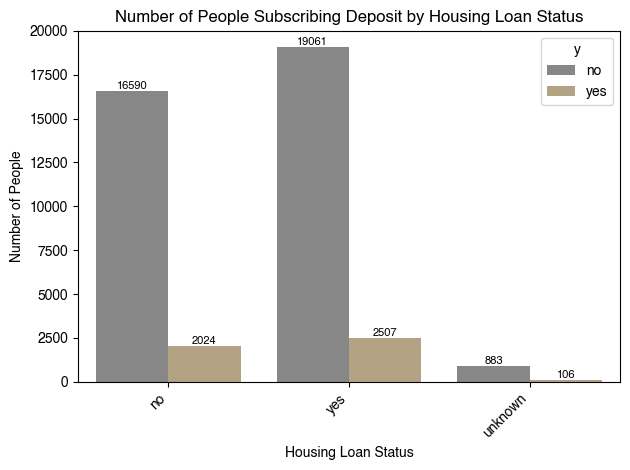

In [58]:
sns.countplot(df_bank_biv, x='housing', hue="y", palette=['#878787','#bca47c'])

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of People Subscribing Deposit by Housing Loan Status')
plt.xlabel('Housing Loan Status')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [59]:
housing_summary = df_bank_biv.groupby('housing')['y'].value_counts().unstack().fillna(0)
housing_summary['Total People Called'] = housing_summary['yes'] + housing_summary['no']

total_dataset_people = len(df_bank_biv)
housing_summary['Housing Proportion %'] = (housing_summary['Total People Called'] / total_dataset_people * 100).round(2)

housing_summary['Conversion Rate %'] = (housing_summary['yes'] / housing_summary['Total People Called'] * 100).round(2)

result = housing_summary[['Total People Called', 'Housing Proportion %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

result = result.sort_values(by='Conversion Rate %', ascending=False)
print(result)

y        Total People Called  Housing Proportion %  People Who Accepted  \
housing                                                                   
yes                    21568                 52.39                 2507   
no                     18614                 45.21                 2024   
unknown                  989                  2.40                  106   

y        Conversion Rate %  
housing                     
yes                  11.62  
no                   10.87  
unknown              10.72  


#### Statistical Findings

Based on the chi-square test, there's NO significant relationship between a housing credit own by the customer and their decision to participate in a bank deposit program. This means that housing is not a key factor in determining customer behavior for this campaign.

##### Housing Credit Analysis

If we ignore the "unknown" category (which constitutes a small percentage of the total population), the groups with and without a housing loan share almost the same proportion of the population and stand at nearly identical conversion rates (with only a 1% difference). This similarity likely explains why the relationship between housing status and the conversion outcome was found to be statistically insignificant.

##### Strategic Recommendation

Since there is no significant bivariate correlation between having a housing loan and the decision to register for a bank deposit, this feature can be prioritized later than others. However, this recommendation may change based on findings from further model deployment.

### 2.5.9 Deposit Subscribtion based on Personal Loan

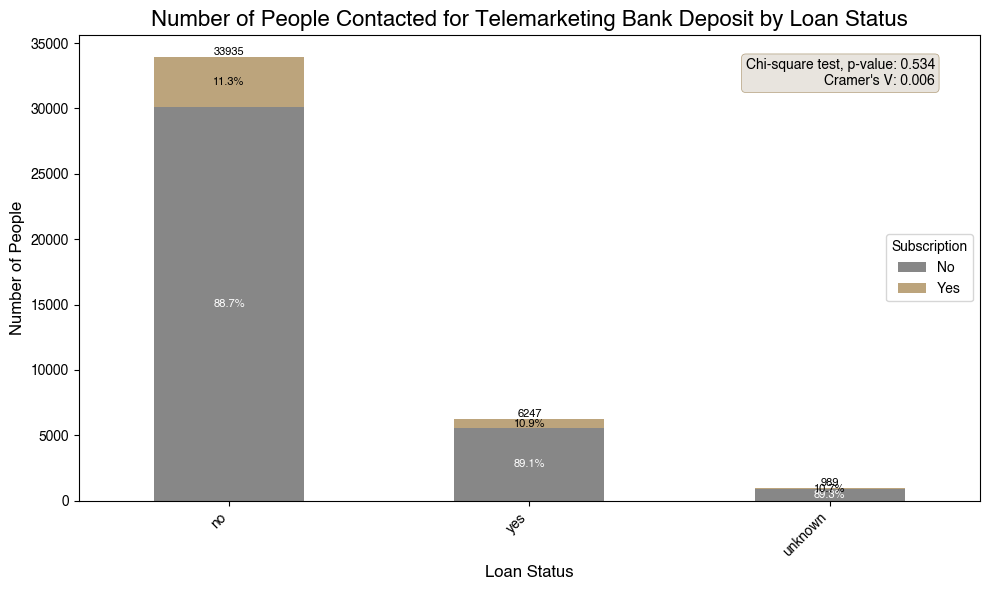

In [60]:
cross_tab_loan = pd.crosstab(df_bank_biv['loan'], df_bank_biv['y'])

cross_tab_loan = cross_tab_loan.reindex(cross_tab_loan.sum(axis=1).sort_values(ascending=False).index)

cross_tab_loan.columns = cross_tab_loan.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_loan.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Loan Status', fontsize=16)
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_loan.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_loan.index):
    total = cross_tab_loan.loc[group].sum()
    yes_count = cross_tab_loan.loc[group]['yes']
    no_count = cross_tab_loan.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_loan)
n = cross_tab_loan.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_loan.shape
cramer_v_loan = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_loan:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

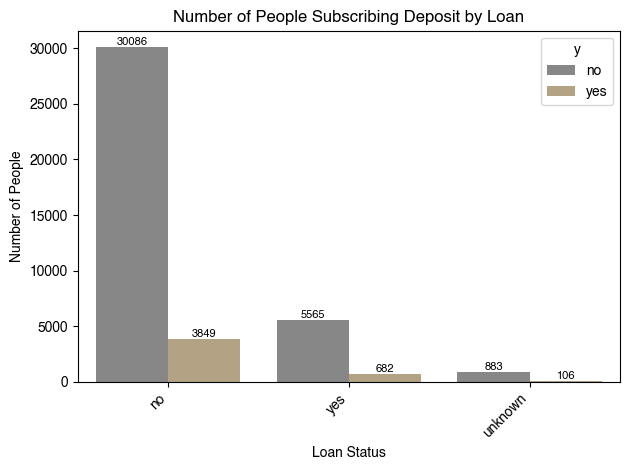

In [61]:
sns.countplot(df_bank_biv, x='loan', hue="y", palette=['#878787','#bca47c'])

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of People Subscribing Deposit by Loan')
plt.xlabel('Loan Status')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [62]:
loan_summary = df_bank_biv.groupby('loan')['y'].value_counts().unstack().fillna(0)
loan_summary['Total People Called'] = loan_summary['yes'] + loan_summary['no']

total_dataset_people = len(df_bank_biv)
loan_summary['Loan Proportion %'] = (loan_summary['Total People Called'] / total_dataset_people * 100).round(2)

loan_summary['Conversion Rate %'] = (loan_summary['yes'] / loan_summary['Total People Called'] * 100).round(2)

result = loan_summary[['Total People Called', 'Loan Proportion %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

result = result.sort_values(by='Conversion Rate %', ascending=False)
print(result)

y        Total People Called  Loan Proportion %  People Who Accepted  \
loan                                                                   
no                     33935              82.42                 3849   
yes                     6247              15.17                  682   
unknown                  989               2.40                  106   

y        Conversion Rate %  
loan                        
no                   11.34  
yes                  10.92  
unknown              10.72  


#### Statistical Findings

Based on the chi-square test, there's NO significant relationship between owning loan and their decision to participate in a bank deposit program. This means that loan is not a key factor in determining customer behavior for this campaign.

##### Loan Analysis

An analysis of the loan proportions and conversion rates for each category reveals a nearly identical pattern. The conversion rates for customers who do not have a loan, have a loan, and have an unknown loan status are all very similar, with a difference of less than 1%. This minimal difference is likely what led to the finding of no statistical significance based on the p-value.


##### Strategic Recommendation

Since there is no significant bivariate correlation between having a personal loan and the decision to register for a bank deposit, this feature can be prioritized later than others. However, this recommendation may change based on findings from further model deployment.

### 2.5.10 Deposit Subscribtion based on Campaign Calls

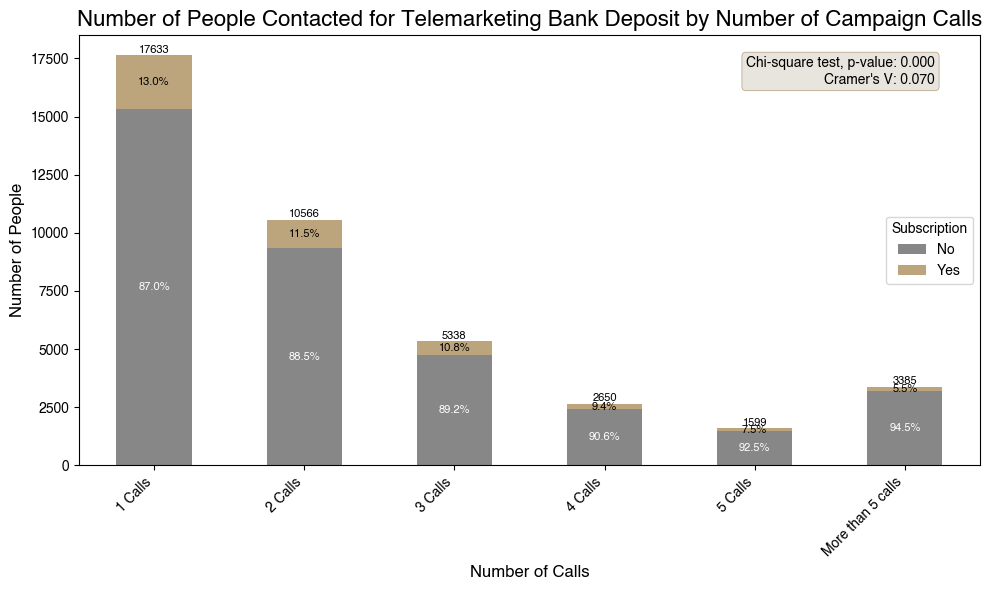

In [63]:
cross_tab_campaign_calls = pd.crosstab(df_bank_biv['campaign_calls'], df_bank_biv['y'])

custom_order = ['1 Calls', '2 Calls', '3 Calls', '4 Calls', '5 Calls', 'More than 5 calls']

cross_tab_campaign_calls = cross_tab_campaign_calls.reindex(custom_order)

cross_tab_campaign_calls.columns = cross_tab_campaign_calls.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_campaign_calls.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Number of Campaign Calls', fontsize=16)
plt.xlabel('Number of Calls', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_campaign_calls.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_campaign_calls.index):
    total = cross_tab_campaign_calls.loc[group].sum()
    yes_count = cross_tab_campaign_calls.loc[group]['yes']
    no_count = cross_tab_campaign_calls.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_campaign_calls)
n = cross_tab_campaign_calls.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_campaign_calls.shape
cramer_v_campaign_calls = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_campaign_calls:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

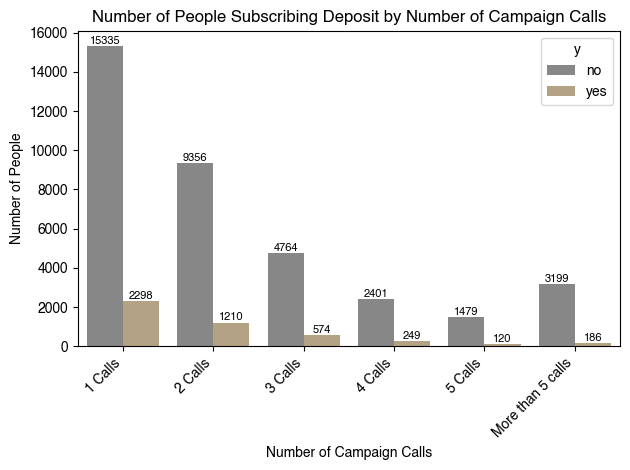

In [64]:
sns.countplot(df_bank_biv, x='campaign_calls', hue="y", palette=['#878787','#bca47c'])

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of People Subscribing Deposit by Number of Campaign Calls')
plt.xlabel('Number of Campaign Calls')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [65]:
campaign_calls_summary = df_bank_biv.groupby('campaign_calls')['y'].value_counts().unstack().fillna(0)
campaign_calls_summary['Total People Called'] = campaign_calls_summary['yes'] + campaign_calls_summary['no']

total_dataset_people = len(df_bank_biv)
campaign_calls_summary['Campaign Calls Proportion %'] = (campaign_calls_summary['Total People Called'] / total_dataset_people * 100).round(2)

campaign_calls_summary['Conversion Rate %'] = (campaign_calls_summary['yes'] / campaign_calls_summary['Total People Called'] * 100).round(2)

result = campaign_calls_summary[['Total People Called', 'Campaign Calls Proportion %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

result = result.sort_values(by='Conversion Rate %', ascending=False)
print(result)

y                  Total People Called  Campaign Calls Proportion %  \
campaign_calls                                                        
1 Calls                          17633                        42.83   
2 Calls                          10566                        25.66   
3 Calls                           5338                        12.97   
4 Calls                           2650                         6.44   
5 Calls                           1599                         3.88   
More than 5 calls                 3385                         8.22   

y                  People Who Accepted  Conversion Rate %  
campaign_calls                                             
1 Calls                           2298              13.03  
2 Calls                           1210              11.45  
3 Calls                            574              10.75  
4 Calls                            249               9.40  
5 Calls                            120               7.50  
More than 5

#### Statistical Findings

Based on the chi-square test, there's significant relationship between the number of campaign calls and their decision to participate in a bank deposit program. This means that campaign calls is a key factor in determining customer behavior for this campaign.

##### Campaign Calls Analysis

Based on the graphs and conversion rate table, the highest conversion rate is from customers who received only one call, at 13.03%. The more calls a customer receives, the less likely they are to accept the bank deposit program. This trend is evident as the conversion rate for the "more than 5 calls" group is the smallest among all groups, even though it includes a higher aggregate number of calls than the 5-call category.

##### Strategic Recommendation

This finding provides a clear recommendation for optimizing the technical strategy of the telemarketing campaign.

The data shows that the highest conversion rate is achieved on the first call, so the team should focus on perfecting the script, timing, and quality of this initial approach. It's advisable to allow for two to three follow-up calls to re-engage customers and encourage them to apply for a deposit. However, if a customer consistently shows a lack of interest after these attempts, it's more efficient to reallocate resources to contact new leads.

Further exploration should be conducted to understand the features and characteristics of telemarketing techniques used in each call. This will provide insights into which specific methods are most successful at securing deposits, especially during the first and second attempts.

### 2.5.11 Deposit Subscribtion based on Number of Days Passed by The Previous Campaign 

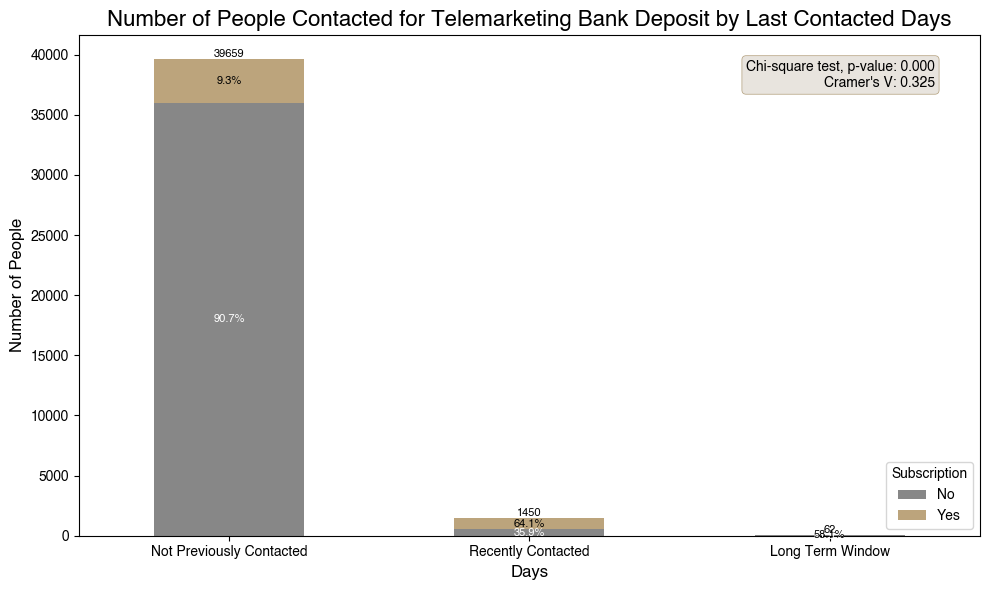

In [66]:
cross_tab_pdays = pd.crosstab(df_bank_biv['pdays_group'], df_bank_biv['y'])

cross_tab_pdays = cross_tab_pdays.reindex(cross_tab_pdays.sum(axis=1).sort_values(ascending=False).index)

cross_tab_pdays.columns = cross_tab_pdays.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_pdays.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Last Contacted Days', fontsize=16)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=360, ha='center')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_pdays.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_pdays.index):
    total = cross_tab_pdays.loc[group].sum()
    yes_count = cross_tab_pdays.loc[group]['yes']
    no_count = cross_tab_pdays.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_pdays)
n = cross_tab_pdays.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_pdays.shape
cramer_v_pdays = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_pdays:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

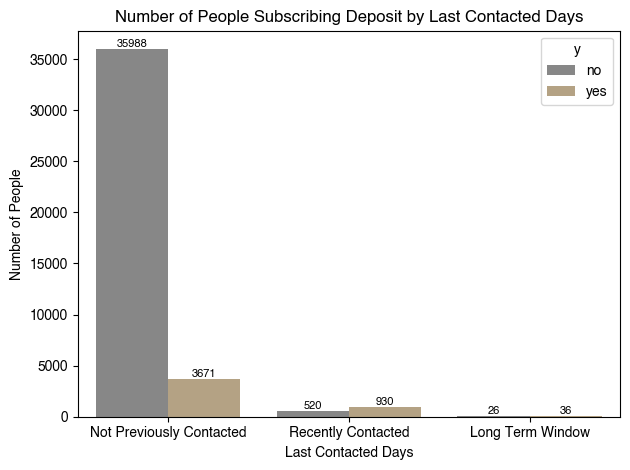

In [67]:
sns.countplot(df_bank_biv, x='pdays_group', hue="y", palette=['#878787','#bca47c'])

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of People Subscribing Deposit by Last Contacted Days')
plt.xlabel('Last Contacted Days')
plt.ylabel('Number of People')
plt.xticks(rotation=360, ha='center')
plt.tight_layout()
plt.show()

In [68]:
pdays1_summary = df_bank_biv.groupby('pdays_group')['y'].value_counts().unstack().fillna(0)
pdays1_summary['Total People Called'] = pdays1_summary['yes'] + pdays1_summary['no']

total_dataset_people = len(df_bank_biv)
pdays1_summary['Pdays Proportion_1 %'] = (pdays1_summary['Total People Called'] / total_dataset_people * 100).round(2)

pdays1_summary['Conversion Rate %'] = (pdays1_summary['yes'] / pdays1_summary['Total People Called'] * 100).round(2)

result = pdays1_summary[['Total People Called','Pdays Proportion_1 %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

result = result.sort_values(by='Conversion Rate %', ascending=False)
print(result)

y                         Total People Called  Pdays Proportion_1 %  \
pdays_group                                                           
Recently Contacted                       1450                  3.52   
Long Term Window                           62                  0.15   
Not Previously Contacted                39659                 96.33   

y                         People Who Accepted  Conversion Rate %  
pdays_group                                                       
Recently Contacted                        930              64.14  
Long Term Window                           36              58.06  
Not Previously Contacted                 3671               9.26  


#### Statistical Findings

Based on the chi-square test, there's significant relationship between the length of days of previous campaign and their decision to participate in a bank deposit program. This means that length of day is a key factor in determining customer behavior for this campaign.

##### Length of Days Previous Campaign Analysis

Based on the graphs and conversion rate table, the highest conversion rates belong to the Recently Contacted and Long-Term Window groups. Both of these categories show conversion rates of more than 50% each. However, the total number of people in these groups is very small, contributing to no more than 5% of the total sample.

In contrast, the group that has no historical contact from a previous bank campaign makes up the vast majority of the population, at 96.33%. Even though this group has a high aggregate number, its success rate is significantly lower compared to the other categories, at only 9.26%.

##### Strategic Recommendation

The prioritization for the next campaign should be adjusted to focus on the most profitable groups.

High Priority: Customers with historical contact. The data shows this group has the highest conversion rates.

Next Priority: New leads (no prior contact). While this group has a lower conversion rate, it represents the largest portion of potential customer base. Continuously acquiring and converting these new customers is essential for long-term business growth.

The current prioritization (Recently Contacted first, then Long-Term Window) is effective, but it's important to remember that these groups are very small. Relying solely on them will not provide a sustainable number of conversions. The most balanced and profitable approach is to heavily prioritize the historical contact groups while maintaining a steady effort to generate and convert new leads. 

### 2.5.12 Deposit Subscribtion Base on Number of Calls of Previous Campaign

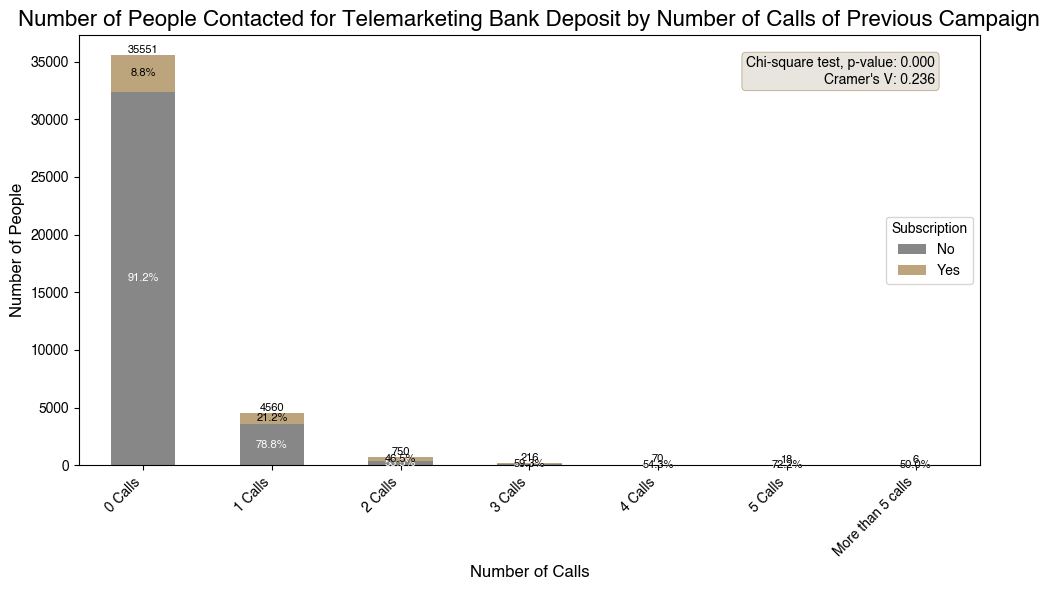

In [69]:
cross_tab_previous = pd.crosstab(df_bank_biv['previous_campaign_calls'], df_bank_biv['y'])

cross_tab_previous = cross_tab_previous.reindex(cross_tab_previous.sum(axis=1).sort_values(ascending=False).index)

cross_tab_previous.columns = cross_tab_previous.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_previous.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Number of Calls of Previous Campaign', fontsize=16)
plt.xlabel('Number of Calls', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_previous.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_previous.index):
    total = cross_tab_previous.loc[group].sum()
    yes_count = cross_tab_previous.loc[group]['yes']
    no_count = cross_tab_previous.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_previous)
n = cross_tab_previous.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_previous.shape
cramer_v_previous = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_previous:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()


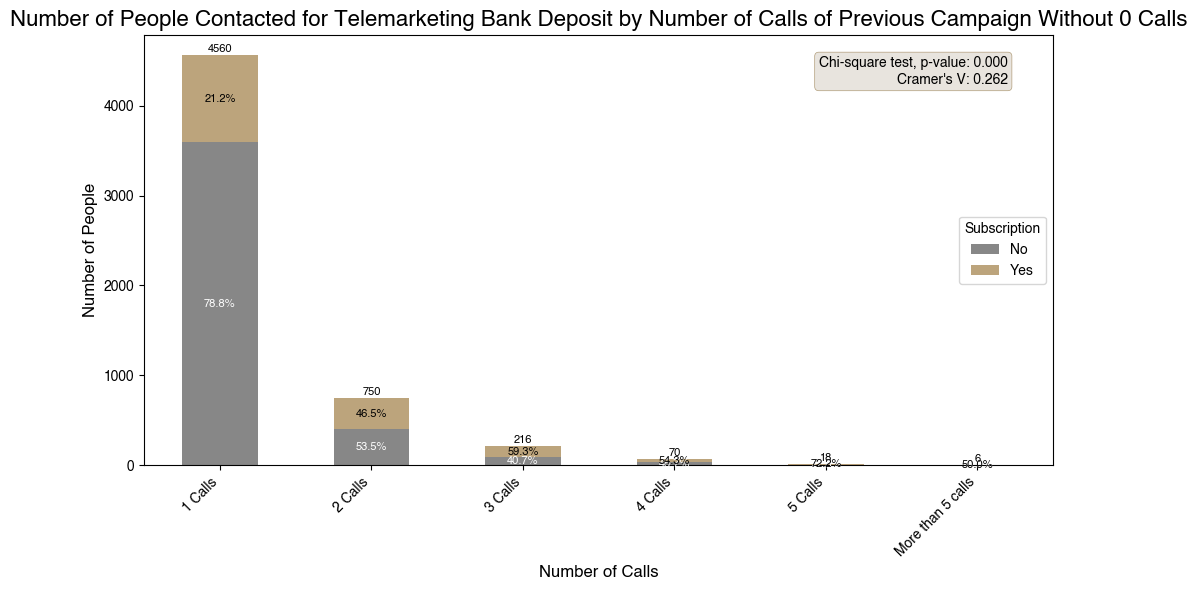

In [70]:
#without 0 calls

df_filtered0 = df_bank_biv[df_bank_biv['previous_campaign_calls'] != '0 Calls']

cross_tab_previous = pd.crosstab(df_filtered0['previous_campaign_calls'], df_filtered0['y'])

cross_tab_previous = cross_tab_previous.reindex(cross_tab_previous.sum(axis=1).sort_values(ascending=False).index)

cross_tab_previous.columns = cross_tab_previous.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_previous.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Number of Calls of Previous Campaign Without 0 Calls', fontsize=16)
plt.xlabel('Number of Calls', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_previous.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_previous.index):
    total = cross_tab_previous.loc[group].sum()
    yes_count = cross_tab_previous.loc[group]['yes']
    no_count = cross_tab_previous.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_previous)
n = cross_tab_previous.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_previous.shape
cramer_v_previous0 = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_previous0:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

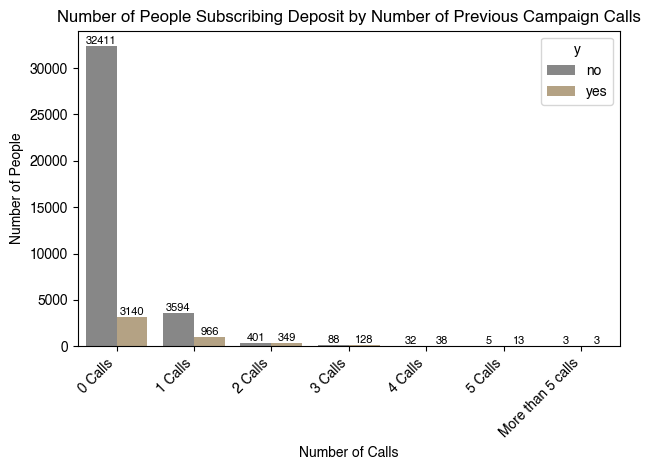

In [71]:
sns.countplot(df_bank_biv, x='previous_campaign_calls', hue="y", palette=['#878787','#bca47c'])

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of People Subscribing Deposit by Number of Previous Campaign Calls')
plt.xlabel('Number of Calls')
plt.ylabel('Number of People')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [72]:
previous_summary = df_bank_biv.groupby('previous_campaign_calls')['y'].value_counts().unstack().fillna(0)
previous_summary['Total People Called'] = previous_summary['yes'] + previous_summary['no']

total_dataset_people = len(df_bank_biv)
previous_summary['Previous Campaign Proportion_1 %'] = (previous_summary['Total People Called'] / total_dataset_people * 100).round(2)

previous_summary['Conversion Rate %'] = (previous_summary['yes'] / previous_summary['Total People Called'] * 100).round(2)

result = previous_summary[['Total People Called','Previous Campaign Proportion_1 %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

result = result.sort_values(by='Conversion Rate %', ascending=False)
print(result)

y                        Total People Called  \
previous_campaign_calls                        
5 Calls                                   18   
3 Calls                                  216   
4 Calls                                   70   
More than 5 calls                          6   
2 Calls                                  750   
1 Calls                                 4560   
0 Calls                                35551   

y                        Previous Campaign Proportion_1 %  \
previous_campaign_calls                                     
5 Calls                                              0.04   
3 Calls                                              0.52   
4 Calls                                              0.17   
More than 5 calls                                    0.01   
2 Calls                                              1.82   
1 Calls                                             11.08   
0 Calls                                             86.35   

y                

#### Statistical Findings

Based on the chi-square test, there's significant relationship between the number of calls of previous campaign and their decision to participate in current bank deposit program. This means that number of calls of previous campaign is a key factor in determining customer behavior for this campaign.

##### Outcome of Previous Campaign Analysis

The provided graphs and conversion rate table demonstrate a positive correlation between the number of calls in a previous campaign and the success rate of a new one. While the group with no prior contact represents the largest segment of the population at 86.35%, its success rate is comparatively low (8.83%). Conversely, a clear trend emerges showing that as the number of previous calls increases, so too does the conversion rate, highlighting a notable performance disparity between new and previously contacted customers.

##### Strategic Recommendation

Given these insights, the telemarketing team should consider the history of other campaigns, as it reveals a different pattern from the current campaign's call data. Although this feature shows a statistically significant relationship, the team should explore whether the number of people contacted in the previous campaign is representative of all customers contacted in previous campaign. Additionally, exploring whether the previous and current programs share similar or different characteristics and if the same customers were contacted in both can provide valuable context for comparing past and current campaigns. This will help refine future targeting strategies.

However, if we connect this to the previous finding (pdays), where people with no prior contact history represent a small percentage, we can assume that telemarketing efforts could be prioritized toward customers who were previously contacted.


### 2.5.13 Deposit Subscribtion Based on Outcome Previous Campaign

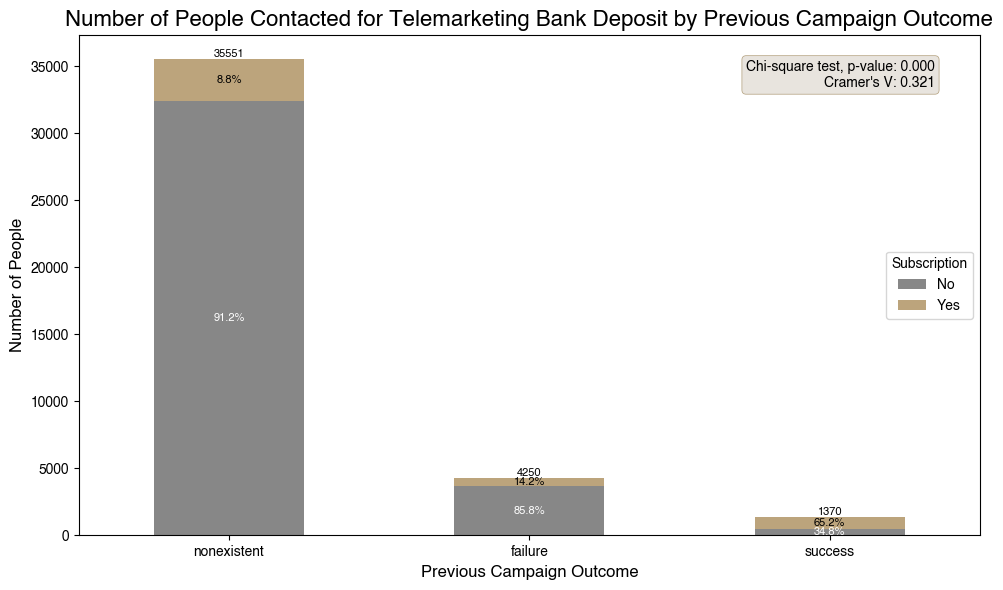

In [73]:
cross_tab_poutcome = pd.crosstab(df_bank_biv['poutcome'], df_bank_biv['y'])

cross_tab_poutcome = cross_tab_poutcome.reindex(cross_tab_poutcome.sum(axis=1).sort_values(ascending=False).index)

cross_tab_poutcome.columns = cross_tab_poutcome.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_poutcome.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Previous Campaign Outcome', fontsize=16)
plt.xlabel('Previous Campaign Outcome', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=360, ha='center')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_poutcome.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_poutcome.index):
    total = cross_tab_poutcome.loc[group].sum()
    yes_count = cross_tab_poutcome.loc[group]['yes']
    no_count = cross_tab_poutcome.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_poutcome)
n = cross_tab_poutcome.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_poutcome.shape
cramer_v_poutcome = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_poutcome:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

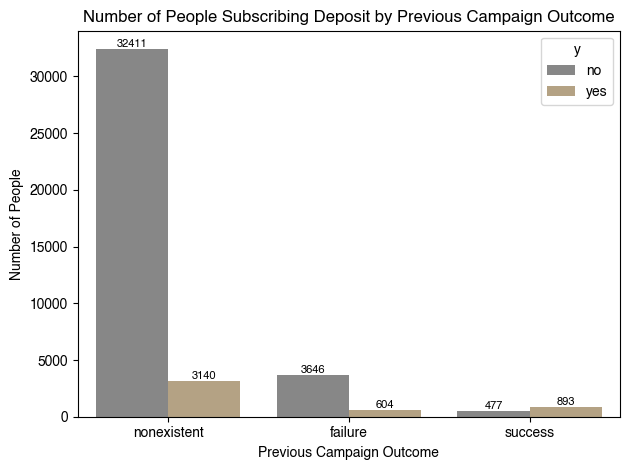

In [74]:
sns.countplot(df_bank_biv, x='poutcome', hue="y", palette=['#878787','#bca47c'])

ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2., h + 5, f'{int(h)}', ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.title('Number of People Subscribing Deposit by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Number of People')
plt.xticks(rotation=360, ha='center')
plt.tight_layout()
plt.show()

In [75]:
poutcome_summary = df_bank_biv.groupby('poutcome')['y'].value_counts().unstack().fillna(0)
poutcome_summary['Total People Called'] = poutcome_summary['yes'] + poutcome_summary['no']

total_dataset_people = len(df_bank_biv)
poutcome_summary['Outcome Previous Campaign Proportion_1 %'] = (poutcome_summary['Total People Called'] / total_dataset_people * 100).round(2)

poutcome_summary['Conversion Rate %'] = (poutcome_summary['yes'] / poutcome_summary['Total People Called'] * 100).round(2)

result = poutcome_summary[['Total People Called','Outcome Previous Campaign Proportion_1 %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

result = result.sort_values(by='Conversion Rate %', ascending=False)
print(result)

y            Total People Called  Outcome Previous Campaign Proportion_1 %  \
poutcome                                                                     
success                     1370                                      3.33   
failure                     4250                                     10.32   
nonexistent                35551                                     86.35   

y            People Who Accepted  Conversion Rate %  
poutcome                                             
success                      893              65.18  
failure                      604              14.21  
nonexistent                 3140               8.83  


In [76]:
# Step 1: Filter the DataFrame to the specific subgroup
target_group_1 = df_bank_biv[
    (df_bank_biv['poutcome'] == 'nonexistent')
]

# Step 2: Find the most frequent job
most_likely_job_1 = target_group_1['job'].mode()[0]

# Step 3: Get a full breakdown of the jobs in this group
job_counts_1 = target_group_1['job'].value_counts()

print(f"The most likely job for a single person aged 18-24 who subscribed is: {most_likely_job_1}")
print("\nBreakdown of jobs within this group:")
print(job_counts_1)

The most likely job for a single person aged 18-24 who subscribed is: admin.

Breakdown of jobs within this group:
job
admin.           8900
blue-collar      8248
technician       5910
services         3449
management       2498
retired          1330
entrepreneur     1277
self-employed    1246
housemaid         948
unemployed        858
student           594
unknown           293
Name: count, dtype: int64


In [77]:
target_group_1 = df_bank_biv[
    (df_bank_biv['previous_campaign_calls'] == '0 Calls')&
    (df_bank_biv['poutcome'] == 'nonexistent')
]

most_likely_job_1 = target_group_1['job'].mode()[0]

print(f"The most frequent job for customers who did NOT subscribe and had no previous contact is: {most_likely_job_1}")

cross_tab_job = pd.crosstab(target_group_1['job'], target_group_1['y'])

cross_tab_job['conversion_rate'] = (
    cross_tab_job['yes'] / (cross_tab_job['yes'] + cross_tab_job['no'])
) * 100

conversion_rates_sorted = cross_tab_job['conversion_rate'].sort_values(ascending=False)

print("\nConversion rates for each job category:")
print(conversion_rates_sorted)

The most frequent job for customers who did NOT subscribe and had no previous contact is: admin.

Conversion rates for each job category:
job
student          24.915825
retired          19.097744
admin.           10.112360
unemployed        9.790210
self-employed     9.229535
management        8.767014
technician        8.138748
entrepreneur      7.987471
unknown           7.508532
housemaid         7.067511
services          6.929545
blue-collar       6.171193
Name: conversion_rate, dtype: float64


#### Statistical Findings

Based on the chi-square test, there's significant relationship between the outcome of previous campaign and their decision to participate in current bank deposit program. In addition, its correlation test result show moderate relationship between these two variables. This means that outcome of previous campaign is a factor in determining customer behavior for this campaign.

##### Outcome of Previous Campaign Analysis

Based on the graphs and conversion rate table, the highest conversion rates belong to the group that had previously accepted another bank product campaign, with a re-acceptance rate of over 60%. However, this group represents the smallest aggregate number of people.

In contrast, individuals who have never been exposed to a bank campaign before have the lowest success rate, despite making up the largest aggregate group. The final group, consisting of people who were contacted in a previous campaign but did not accept the product, has a conversion rate of about 14%.

##### Strategic Recommendation

The telemarketing team should explore the possibility of re-contacting customers who previously accepted a bank product campaign, as this group offers the highest potential for increasing the conversion rate. The team can then focus on the group that was previously contacted (but did not accept a product) before engaging with new customers.

In addition to the history of previously not contacted and unknown outcome (engaging new prospect customers), telemarketer could outreach student and retired people as target priority to create potential new leads, then move to others type of job like admin, unemployed and self-employed people. 

### 2.5.14 Deposit Subscribtion Based on Celluler vs Telephone

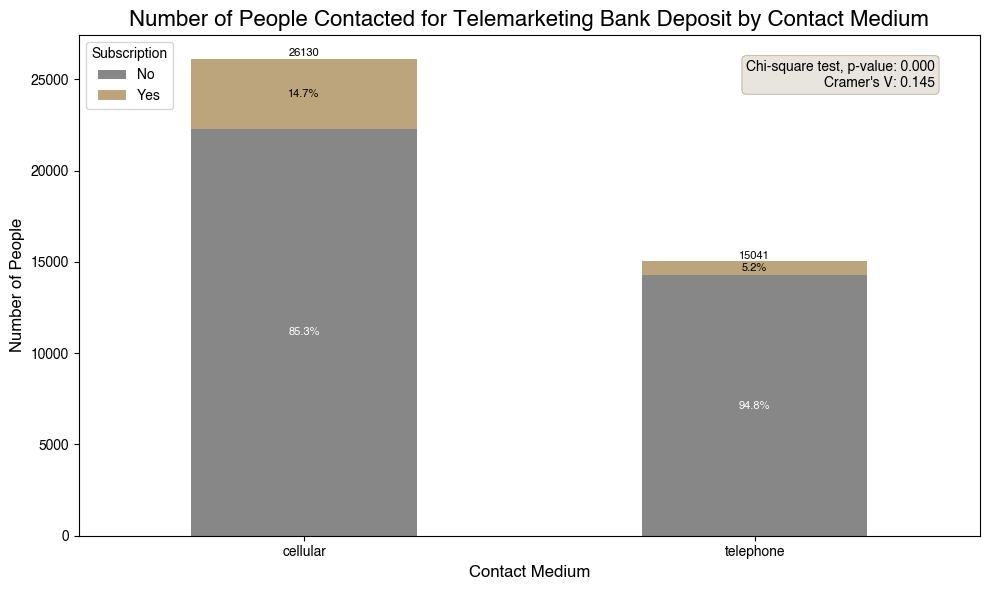

In [78]:
cross_tab_contact = pd.crosstab(df_bank_biv['contact'], df_bank_biv['y'])

cross_tab_contact = cross_tab_contact.reindex(cross_tab_contact.sum(axis=1).sort_values(ascending=False).index)

cross_tab_contact.columns = cross_tab_contact.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_contact.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Contact Medium', fontsize=16)
plt.xlabel('Contact Medium', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=360, ha='center')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_contact.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_contact.index):
    total = cross_tab_contact.loc[group].sum()
    yes_count = cross_tab_contact.loc[group]['yes']
    no_count = cross_tab_contact.loc[group]['no']
    
    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100
    
    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_contact)
n = cross_tab_contact.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_contact.shape
cramer_v_contact = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
         f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_contact:.3f}',
         transform=ax.transAxes,
         fontsize=10, ha='right', va='top',
         bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

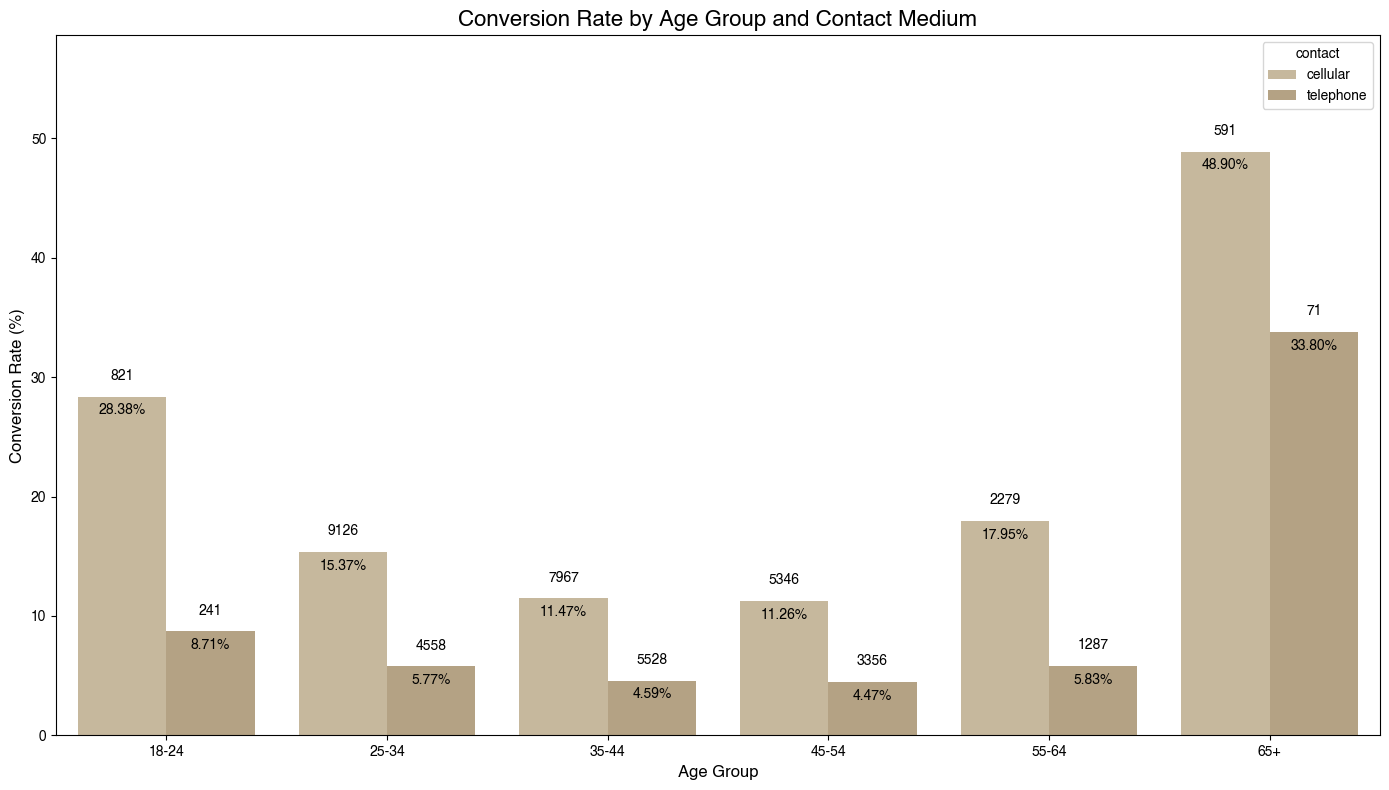

In [79]:
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
plot_data = df_bank_biv[df_bank_biv['contact'] != 'unknown']

cross_tab_data = plot_data.groupby(['age_group', 'contact', 'y']).size().unstack(fill_value=0).reset_index()

cross_tab_data['total_people'] = cross_tab_data['yes'] + cross_tab_data['no']
cross_tab_data['conversion_rate'] = (cross_tab_data['yes'] / cross_tab_data['total_people']) * 100

final_plot_data = cross_tab_data[cross_tab_data['total_people'] > 0]

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=final_plot_data,
    x='age_group',
    y='conversion_rate',
    hue='contact',
    palette=['#CDBA96','#bca47c'],
    order=age_order
)
plt.title('Conversion Rate by Age Group and Contact Medium', fontsize=16)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.xticks(rotation=0, ha='center')
plt.ylim(0, final_plot_data['conversion_rate'].max() * 1.2)
plt.tight_layout()

for p in ax.patches:
    bar_height = p.get_height()
    x_pos = p.get_x() + p.get_width() / 2
    
    matching_data = final_plot_data[
        (abs(final_plot_data['conversion_rate'] - bar_height) < 0.01) 
    ]
    
    if len(matching_data) > 1:
        contact_type = 'cellular' if x_pos < ax.get_xticks()[int(p.get_x())] else 'telephone'
        matching_data = matching_data[matching_data['contact'] == contact_type]

    if not matching_data.empty:
        total_count = matching_data['total_people'].iloc[0]
        
        ax.annotate(f"{total_count}", 
                     (p.get_x() + p.get_width() / 2., bar_height),
                     ha='center', va='center', fontsize=10, color='black', xytext=(0, 15),
                     textcoords='offset points')
        
        if bar_height > 0:
            ax.annotate(f"{bar_height:.2f}%", 
                         (p.get_x() + p.get_width() / 2., bar_height),
                         ha='center', va='center', fontsize=10, color='black', xytext=(0, -10),
                         textcoords='offset points')

In [80]:
contact_summary = df_bank_biv.groupby('contact')['y'].value_counts().unstack().fillna(0)
contact_summary['Total People Called'] = contact_summary['yes'] + contact_summary['no']

total_dataset_people = len(df_bank_biv)
contact_summary['Contact Medium Proportion_1 %'] = (contact_summary['Total People Called'] / total_dataset_people * 100).round(2)

contact_summary['Conversion Rate %'] = (contact_summary['yes'] / contact_summary['Total People Called'] * 100).round(2)

result = contact_summary[['Total People Called', 'Contact Medium Proportion_1 %', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})

result = result.sort_values(by='Conversion Rate %', ascending=False)
print(result)

y          Total People Called  Contact Medium Proportion_1 %  \
contact                                                         
cellular                 26130                          63.47   
telephone                15041                          36.53   

y          People Who Accepted  Conversion Rate %  
contact                                            
cellular                  3850              14.73  
telephone                  787               5.23  


#### Statistical Findings

Based on the chi-square test, there's significant relationship between contact medium and their decision to participate in a bank deposit program even its correlation show a weak connection between these two features.

##### Contact Mode Analysis

Overall, the graphs and conversion rate table show that cellular phone usage is significantly higher than landline telephones in the campaign. This is reflected in a much larger conversion rate for cellular contacts (more than double the rate for landlines).

Furthermore, a deeper analysis of contact methods across different age groups reveals a consistent trend: cellular phones are not only used more frequently but also have a higher conversion rate across the board.

As an additional insight, it is worth noting that the success rate of contacting the elderly group via telephone is quite high compared to other demographics. While most groups have a telephone conversion rate below 10%, the elderly group shows a success rate of over 30%.

##### Strategic Recommendation

This finding provides strategic insight into which contact method has a better chance of increasing the conversion rate: cellular phones. The consistent pattern across all age groups shows that cellular phones are a relevant and effective communication tool for all customer types.

However, an additional insight should be considered for the elderly group. Since both cellular and landline telephone contact methods show a significant conversion rate for this demographic, reaching this group could be optimized by using both methods. This accounts for the possibility that some elderly individuals may be more comfortable using traditional communication tools.

### 2.5.15 Deposit Subscription Based on Days and Month

#### 2.5.15.1 Month

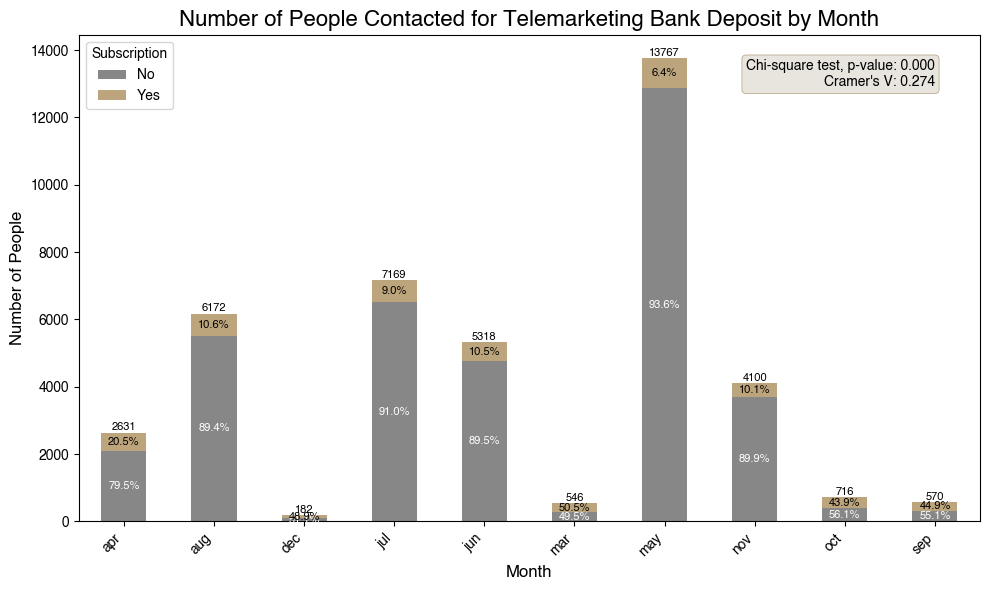

In [81]:
cross_tab_month = pd.crosstab(df_bank_biv['month'], df_bank_biv['y'])

month_order = ['mar','apr','may','jun','jul','aug','sep','oct','nov','dec']

cross_tab_day = cross_tab_month.reindex(month_order)

cross_tab_month.columns = cross_tab_month.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_month.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_month.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_month.index):
    total = cross_tab_month.loc[group].sum()
    yes_count = cross_tab_month.loc[group]['yes']
    no_count = cross_tab_month.loc[group]['no']

    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100

    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_month)
n = cross_tab_month.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_month.shape
cramer_v_month = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_month:.3f}',
transform=ax.transAxes,
fontsize=10, ha='right', va='top',
bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

In [82]:
conversion_counts = df_bank_biv.groupby('month')['y'].value_counts().unstack().fillna(0)

conversion_counts['Total People Called'] = conversion_counts['yes'] + conversion_counts['no']

conversion_counts['Conversion Rate %'] = (conversion_counts['yes'] / conversion_counts['Total People Called'] * 100).round(2)

result = conversion_counts[['Total People Called', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})
result = result.sort_values(by='Conversion Rate %', ascending=False)

print(result)

y      Total People Called  People Who Accepted  Conversion Rate %
month                                                             
mar                    546                  276              50.55
dec                    182                   89              48.90
sep                    570                  256              44.91
oct                    716                  314              43.85
apr                   2631                  539              20.49
aug                   6172                  654              10.60
jun                   5318                  559              10.51
nov                   4100                  416              10.15
jul                   7169                  648               9.04
may                  13767                  886               6.44


#### 2.5.15.2 Day

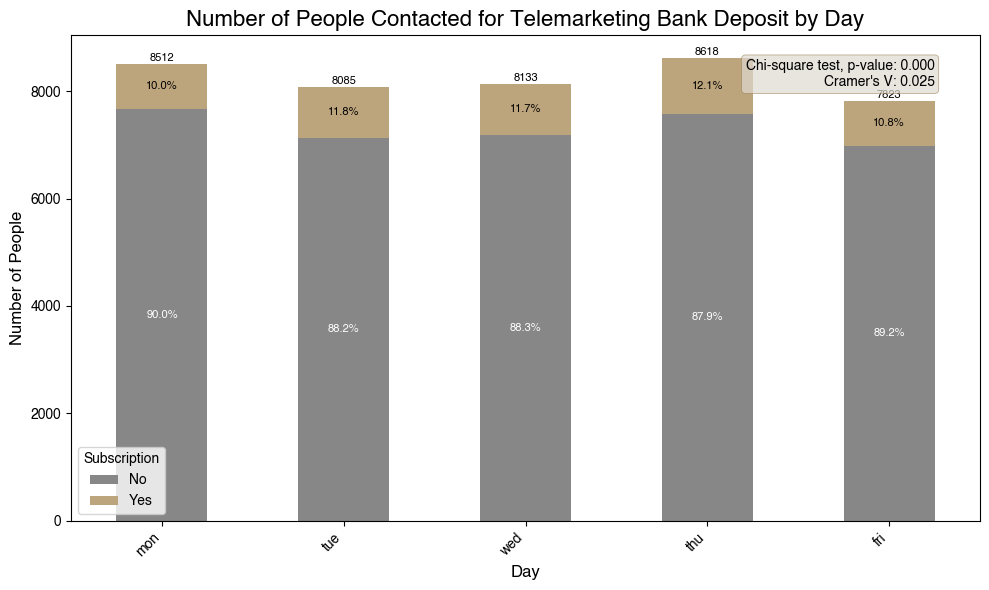

In [83]:
cross_tab_day = pd.crosstab(df_bank_biv['day_of_week'], df_bank_biv['y'])

day_order = ['mon', 'tue','wed','thu','fri']

cross_tab_day = cross_tab_day.reindex(day_order)

cross_tab_day.columns = cross_tab_day.columns.str.lower()

colors = ['#878787','#bca47c']

ax = cross_tab_day.plot(kind='bar', stacked=True, figsize=(10, 6), color=colors)
plt.title('Number of People Contacted for Telemarketing Bank Deposit by Day', fontsize=16)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Number of People', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Subscription', labels=['No', 'Yes'])
plt.grid(axis='y', linestyle='', alpha=0.7)
plt.tight_layout()

for i, total in enumerate(cross_tab_day.sum(axis=1)):
    ax.text(i, total + 10, f'{int(total)}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i, group in enumerate(cross_tab_day.index):
    total = cross_tab_day.loc[group].sum()
    yes_count = cross_tab_day.loc[group]['yes']
    no_count = cross_tab_day.loc[group]['no']

    yes_rate = (yes_count / total) * 100
    no_rate = (no_count / total) * 100

    ax.text(i, no_count / 2, f'{no_rate:.1f}%', ha='center', va='center', color='white', fontsize=8)
    ax.text(i, no_count + yes_count / 2, f'{yes_rate:.1f}%', ha='center', va='center', color='black', fontsize=8)

chi2, p_value, dof, expected = stats.chi2_contingency(cross_tab_day)
n = cross_tab_day.sum().sum()
phi2 = chi2 / n
r, k = cross_tab_day.shape
cramer_v_day = np.sqrt(phi2 / min(r-1, k-1))

plt.text(0.95, 0.95,
f'Chi-square test, p-value: {p_value:.3f}\nCramer\'s V: {cramer_v_day:.3f}',
transform=ax.transAxes,
fontsize=10, ha='right', va='top',
bbox=dict(boxstyle="round,pad=0.3", fc="#dfd9d0", ec="#967b4b", lw=0.5, alpha=0.7))

plt.show()

In [84]:
conversion_counts = df_bank_biv.groupby('day_of_week')['y'].value_counts().unstack().fillna(0)

conversion_counts['Total People Called'] = conversion_counts['yes'] + conversion_counts['no']

conversion_counts['Conversion Rate %'] = (conversion_counts['yes'] / conversion_counts['Total People Called'] * 100).round(2)

result = conversion_counts[['Total People Called', 'yes', 'Conversion Rate %']]
result = result.rename(columns={'yes': 'People Who Accepted'})
result = result.sort_values(by='Conversion Rate %', ascending=False)

print(result)

y            Total People Called  People Who Accepted  Conversion Rate %
day_of_week                                                             
thu                         8618                 1044              12.11
tue                         8085                  952              11.77
wed                         8133                  949              11.67
fri                         7823                  845              10.80
mon                         8512                  847               9.95


#### Statistical Findings

Based on the chi-square test, there's significant relationship between both month and day of week to their decision to participate in a bank deposit program. If the month shows moderate correlation, days showing the weak relationship to the feature target. 

##### Month Analysis

The explanation of month will be gathered with Macroeconomic indicator trend. 

##### Day Analysis

There are slight differences in the number of calls and conversion rates across different days of the week, but the overall conversion rates are not significantly different, ranging from 9.5% to 12.5%. Thursday has both the highest number of calls and the highest conversion rate (12.11%). Tuesday and Wednesday follow with a very small difference in conversion rate (0.10%). Monday has the lowest conversion rate at 9.95%.

##### Strategic Recommendation

Based on the statistical findings and the provided bar chart, the telemarketing team should consider optimizing their efforts in the middle of the week (Tuesday, Wednesday, and Thursday), as these days yield the highest conversion rates. Avoiding Monday and Friday could also be considered, as some sources suggest avoiding these days. On Mondays, people are often busy with office activities, while on Fridays, they are typically preparing for the weekend.

### 2.5.16 Deposit Subscribtion Based on Macroeconomic Indicator

#### 2.5.16.1 Distribution of Target Based on the Macroeconomic Indicator

--- Statistical Analysis ---

- emp.var.rate:
  Mann-Whitney U Test p-value: 0.0000
  Conclusion: There is a statistically significant difference in the medians of the two groups.
  Spearman's Rho: -0.2473
  Spearman's p-value: 0.0000
  Conclusion: There is a statistically significant monotonic relationship.

- cons.price.idx:
  Mann-Whitney U Test p-value: 0.0000
  Conclusion: There is a statistically significant difference in the medians of the two groups.
  Spearman's Rho: -0.1220
  Spearman's p-value: 0.0000
  Conclusion: There is a statistically significant monotonic relationship.

- cons.conf.idx:
  Mann-Whitney U Test p-value: 0.0000
  Conclusion: There is a statistically significant difference in the medians of the two groups.
  Spearman's Rho: 0.0409
  Spearman's p-value: 0.0000
  Conclusion: There is a statistically significant monotonic relationship.

- euribor3m:
  Mann-Whitney U Test p-value: 0.0000
  Conclusion: There is a statistically significant difference in the media

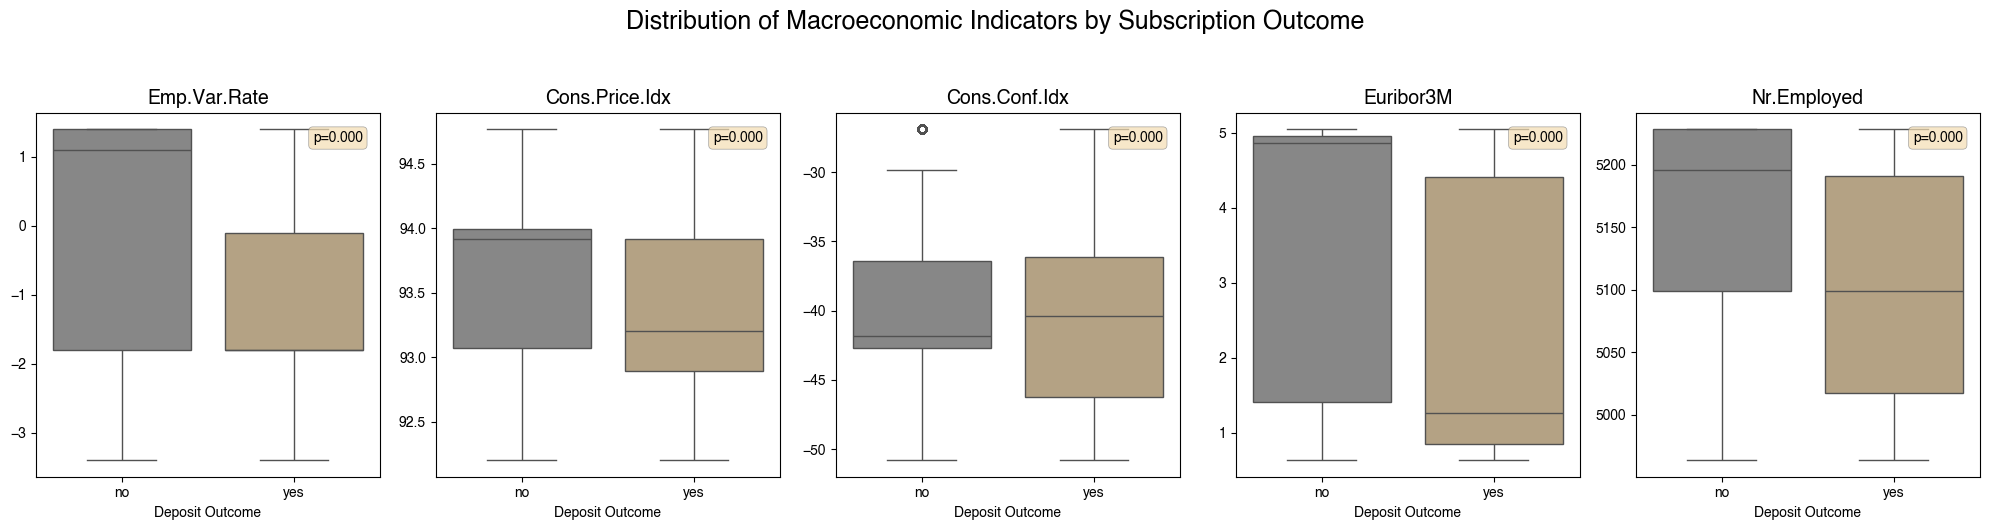

In [85]:
indicators = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

df_bank_biv['y_encoded'] = df_bank_biv['y'].apply(lambda x: 1 if x == 'yes' else 0)

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 5), sharey=False)
colors = ['#878787', '#bca47c']

print("--- Statistical Analysis ---")

for i, indicator in enumerate(indicators):
    yes_group = df_bank_biv[df_bank_biv['y'] == 'yes'][indicator]
    no_group = df_bank_biv[df_bank_biv['y'] == 'no'][indicator]

    u_statistic, p_value_mw = stats.mannwhitneyu(yes_group, no_group, alternative='two-sided')
    
    rho, p_value_spearman = stats.spearmanr(df_bank_biv[indicator], df_bank_biv['y_encoded'])

    print(f"\n- {indicator}:")
    print(f"  Mann-Whitney U Test p-value: {p_value_mw:.4f}")
    if p_value_mw < 0.05:
        print("  Conclusion: There is a statistically significant difference in the medians of the two groups.")
    else:
        print("  Conclusion: There is no statistically significant difference in the medians of the two groups.")
    
    print(f"  Spearman's Rho: {rho:.4f}")
    print(f"  Spearman's p-value: {p_value_spearman:.4f}")
    if p_value_spearman < 0.05:
        print("  Conclusion: There is a statistically significant monotonic relationship.")
    else:
        print("  Conclusion: There is no statistically significant monotonic relationship.")

    sns.boxplot(
        x='y',
        y=indicator,
        data=df_bank_biv,
        palette=colors,
        ax=axes[i]
    )
    
    axes[i].set_title(indicator.replace('_', ' ').title(), fontsize=14)
    axes[i].set_xlabel('Deposit Outcome')
    axes[i].set_ylabel('')
    
    axes[i].text(0.95, 0.95, f'p={p_value_mw:.3f}', transform=axes[i].transAxes,
                 fontsize=10, ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', ec='gray', lw=0.5, alpha=0.7))

fig.suptitle('Distribution of Macroeconomic Indicators by Subscription Outcome', fontsize=18, y=1.05)
plt.tight_layout()
plt.savefig('economic_indicators_analysis_with_pvalues.png')
plt.show()

#### 2.5.16.2 Subscribtion based on Month and 5 Macro Economic Indicator

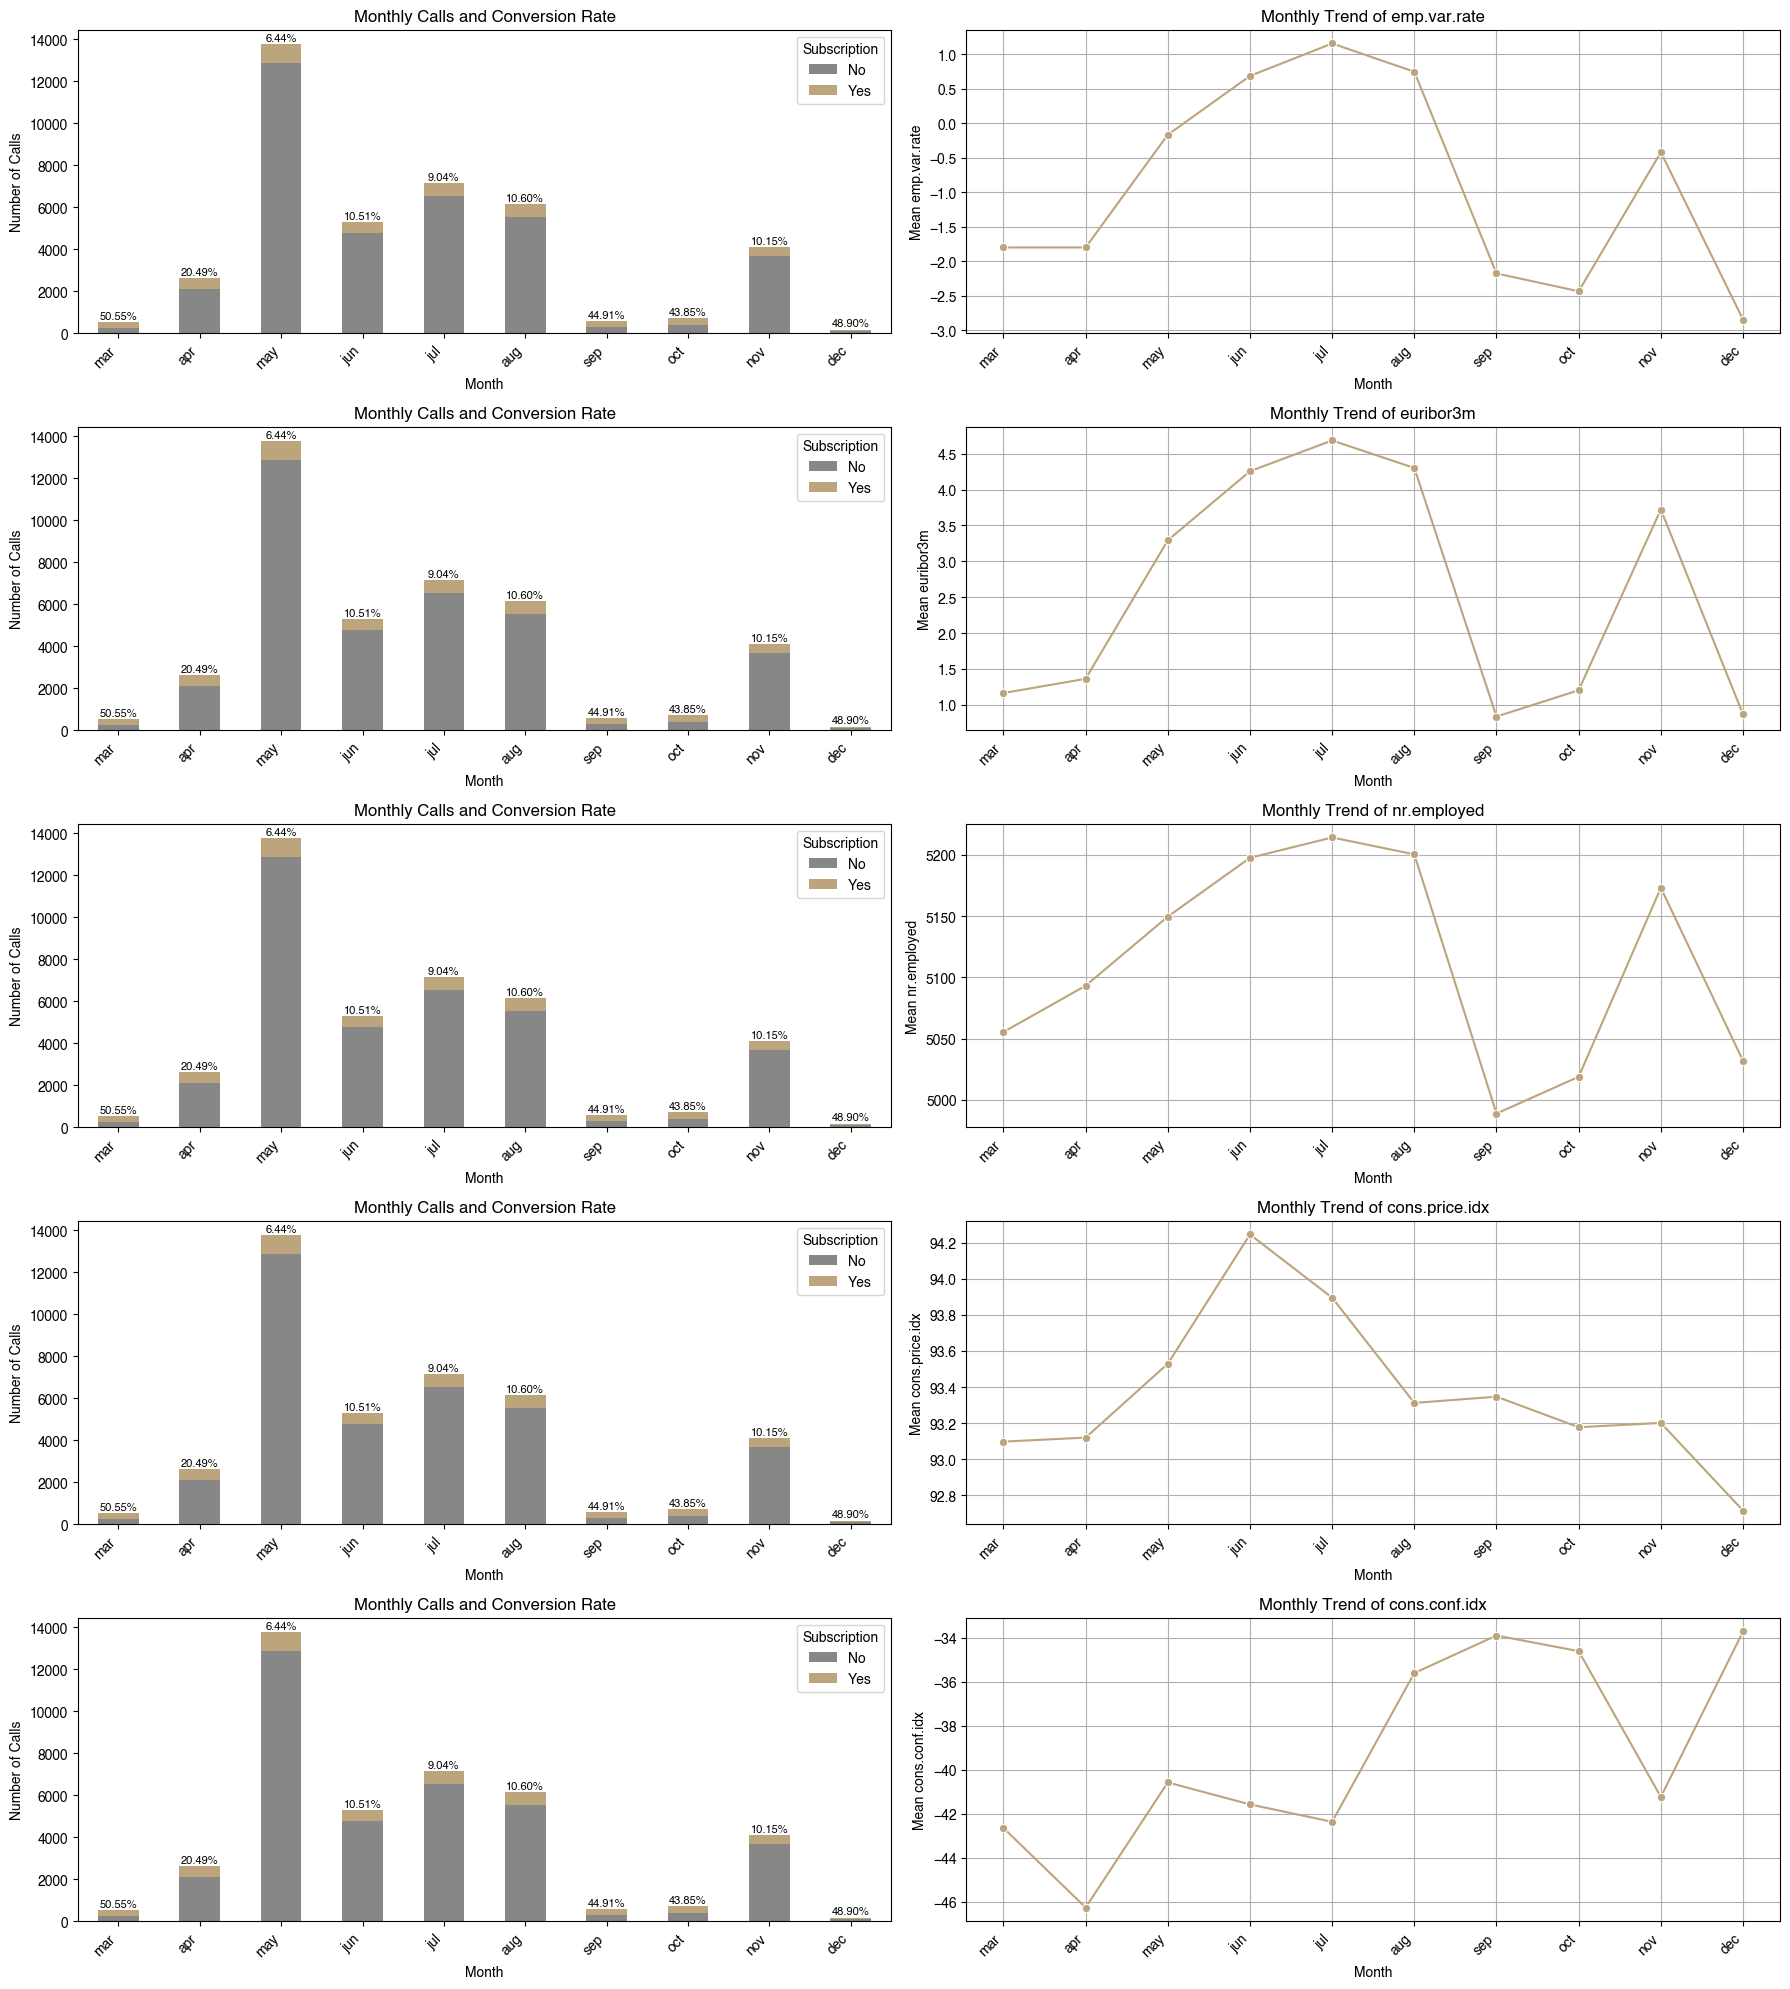

In [86]:
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
df_bank_biv['month'] = pd.Categorical(df_bank_biv['month'], categories=month_order, ordered=True)

monthly_means = df_bank_biv.groupby('month')[['emp.var.rate', 'euribor3m','nr.employed','cons.price.idx','cons.conf.idx']].mean().reset_index()

y_counts = df_bank_biv.groupby(['month', 'y']).size().unstack(fill_value=0).reindex(month_order)
conversion_rates = (y_counts['yes'] / (y_counts['yes'] + y_counts['no'])) * 100

variables = ['emp.var.rate', 'euribor3m','nr.employed','cons.price.idx','cons.conf.idx']

fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(18, 20))

for i, var in enumerate(variables):
    ax_bar = axs[i, 0]
    y_counts.plot(kind='bar', stacked=True, ax=ax_bar, color=['#878787', '#bca47c'])
    ax_bar.set_title(f'Monthly Calls and Conversion Rate', fontsize=12)
    ax_bar.set_xlabel('Month')
    ax_bar.set_ylabel('Number of Calls')
    ax_bar.set_xticklabels(month_order, rotation=45, ha='right')
    ax_bar.legend(title='Subscription', labels=['No', 'Yes'])

    for j, month in enumerate(month_order):
        total_count = y_counts.loc[month].sum()
        rate = conversion_rates.loc[month]
        ax_bar.text(j, total_count + 50, f'{rate:.2f}%', ha='center', va='bottom', fontsize=8)

    ax_line = axs[i, 1]
    sns.lineplot(data=monthly_means, x='month', y=var, ax=ax_line, marker='o', color='#bca47c')
    ax_line.set_title(f'Monthly Trend of {var}', fontsize=12)
    ax_line.set_xlabel('Month')
    ax_line.set_ylabel(f'Mean {var}')
    ax_line.set_xticklabels(month_order, rotation=45, ha='right')
    ax_line.grid(True)

plt.tight_layout()
plt.show()

#### Statistical Findings

Based on the chi-square test, there is a significant relationship between all the macroeconomic indicators and the decision to subscribe to a bank deposit program.

Key Findings:

Inverse Correlation: emp.var.rate, nr.employed, and euribor3m have an inverse correlation with deposit subscriptions. When the scores for these three indicators are low, more people are likely to subscribe to a bank deposit.

Direct Correlation: cons.price.idx and cons.conf.idx show a direct correlation with the decision to apply for a deposit.

Note: Your initial draft says "linear," but based on our previous discussions and the graphs you provided, the relationship is inverse, not direct. A low consumer confidence/price index corresponds to a higher conversion rate. Therefore, the corrected statement should reflect this inverse relationship. I've adjusted this to align with the data and logic.

##### Macroeconomic Analysis

Based on the graph, three macroeconomic indicators—emp.var.rate, euribor3m, and nr.employed—show a similar trend. This trend is also mirrored in the number of customers contacted each month.

In March and April, a small number of customers were contacted, and the three macroeconomic indicators were also at lower values. Moreover, September, October, and December also show a low number of contacts and low values for the same three indicators. Interestingly, the conversion rate for these months is higher compared to May, June, July, and November.

Two other macroeconomic indicators, cons.price.idx and cons.conf.idx, show different trends. The cons.price.idx generally follows the same trend as the other three indicators but with some key differences. For instance, while the other three indicators declined in September, cons.price.idx showed its decline earlier in July. Additionally, cons.price.idx had only a slight increase in November, whereas the other three indicators showed a significant rise.

Finally, cons.conf.idx appears to have a trend opposite to the three similar macroeconomic indicators. When those three indicators decrease, cons.conf.idx shows an increase.

##### Strategic Recommendation

Given the continuous and challenging nature of predicting macroeconomic indicators, it is crucial to monitor them while conducting telemarketing. Certain indicators—such as emp.var.rate, nr.employed, euribor3m, and cons.conf.idx—are likely to impact people's decisions to apply for a bank deposit.

When these indicators are low, it signals a shrinking job market and economic uncertainty. This makes people prioritize financial safety. For banks, this presents a strong opportunity to encourage individuals to secure their money in a deposit through telemarketing, even if the interest rate is low.

Conversely, when these four indicators are high, people may be more inclined to seek assets that offer higher returns, even if they carry more risk than a deposit. Therefore, the telemarketing approach must be adjusted. Telemarketers should provide insights and arguments as to why a deposit can still be a valuable asset to hold, ultimately persuading the customer to subscribe.


Note :

- emp.var.rate
A low (negative) emp.var.rate means the job market is shrinking. This insecurity makes people fear losing their jobs, so they prioritize saving for a safety net. A bank deposit is the safest option for this, leading to a high conversion rate.

- nr.employed
A low nr.employed value confirms a weak job market. This reinforces a consumer mindset of fear and caution. People save money to prepare for a "rainy day," making bank deposits highly appealing despite low returns. This results in a high conversion rate.

- euribor3m
A low euribor3m rate means banks are getting cheap money, so they don't need consumer deposits and offer very low interest rates. However, in a weak economy, consumers are focused on safety, not profit. They will accept the low return to secure their money, leading to a high conversion rate.

- cons.price.idx
A low cons.price.idx indicates low inflation or stable prices, which is common in a weak economy with low demand. This economic uncertainty causes consumers to reduce spending and increase saving. A bank deposit is a secure place to store this savings, leading to a high conversion rate.

- cons.conf.idx
A low cons.conf.idx shows that consumers are pessimistic about the economy. This lack of confidence drives a defensive financial strategy. It can be lead to different behaviour of spending the saving. In this scenario, it islikely that the lower confidence will make them hold their funds into a highly liquid checking account compare to deposit.

### Heatmap Correlation Test

This to show at a glance the strength and direction correlation of the features to the target. Details explanation already included on the each features section.

#### Numerical Features to Target

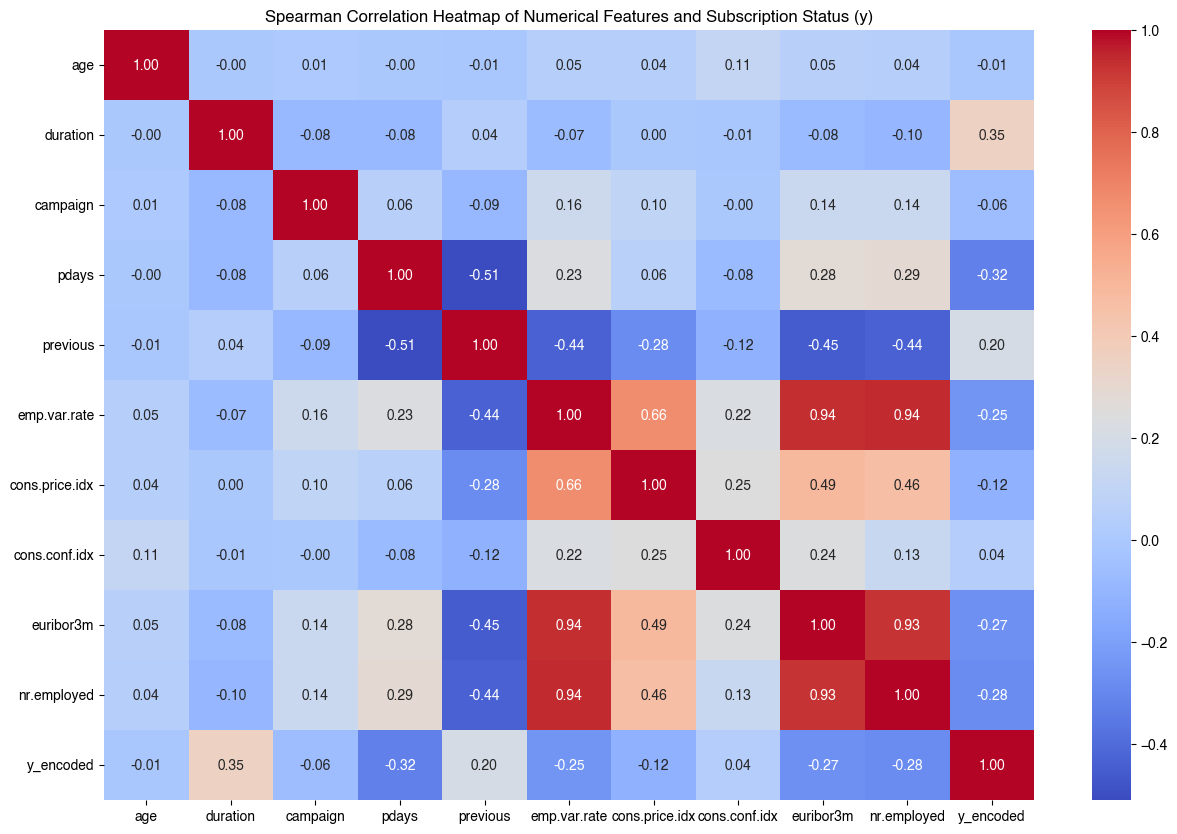


Spearman Correlation with 'y' (encoded):
y_encoded         1.000000
duration          0.348784
previous          0.200933
cons.conf.idx     0.041127
age              -0.011913
campaign         -0.063655
cons.price.idx   -0.122123
emp.var.rate     -0.247427
euribor3m        -0.266772
nr.employed      -0.283912
pdays            -0.324975
Name: y_encoded, dtype: float64


In [87]:
df_copy = df_bank.copy()

df_copy['y_encoded'] = df_copy['y'].apply(lambda x: 1 if x == 'yes' else 0)

features = df_copy.select_dtypes(include=['float64', 'int64']).columns.tolist()

corr_matrix_spearman = df_copy[features].corr(method='spearman')

plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix_spearman, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Spearman Correlation Heatmap of Numerical Features and Subscription Status (y)')
plt.show()

y_corr_spearman = corr_matrix_spearman['y_encoded'].sort_values(ascending=False)
print("\nSpearman Correlation with 'y' (encoded):")
print(y_corr_spearman)

#### Categorical Features to Target

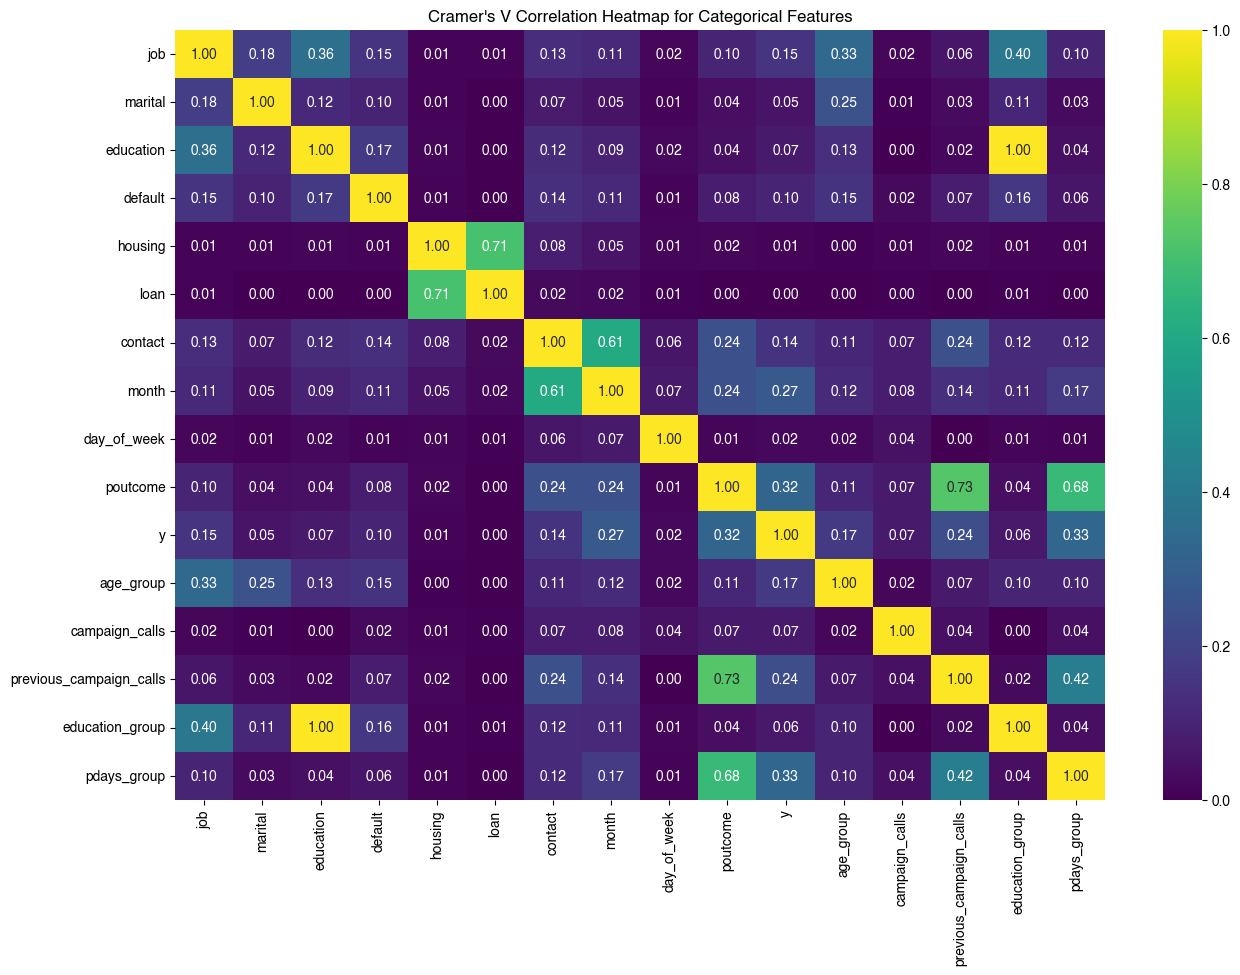

In [88]:
categorical_df = df_bank_biv.select_dtypes(include=['object', 'category'])
cramers_v_corr = associations(
    categorical_df,
    nominal_columns='all',
    plot=False,
    mark_columns=False
)['corr']

plt.figure(figsize=(15, 10))
sns.heatmap(cramers_v_corr, annot=True, cmap='viridis', fmt=".2f")
plt.title("Cramer's V Correlation Heatmap for Categorical Features")
plt.show()


# 3. Conclusion

Most features have a significant impact on a person's decision to apply for a deposit. Only two variables—housing and loan features—do not show a significant relationship. This analysis provides several suggestions for future telemarketing strategies:

### Individual Characteristics
- Age: Customers in the 18-24 and 65+ age groups have higher conversion rates. Given the small proportion of people currently contacted in these groups, there's an opportunity to reach out to more leads.
- Marital Status: Single people have a higher conversion rate and represent a strong potential group for future telemarketing. However, some married individuals, such as retirees, also show potential for successful conversions.
- Education: Individuals with higher education may have greater potential as program leads.
- Job: Students and retirees have the highest potential conversion rates.


### Credit/Loan Status
- Housing Loan: There is no significant relationship between a housing loan and the decision to subscribe to a deposit.
- Personal Loan: There is no significant relationship between a personal loan and the decision to subscribe to a deposit.
- Credit: There is a significant relationship between credit default status and the decision to subscribe to a deposit.


### Previous Campaign History
- Previous Contact Date: The analysis suggests that telemarketers should prioritize individuals who were contacted in previous campaigns, specifically within the 0 to 14-day window following the last contact.
- Number of Previous Contacts: The data shows that a higher number of previous contacts correlates with a higher conversion rate. However, because the proportion of people who were not contacted is small, the marketing team should use this recommendation with caution.
- Previous Campaign Outcome: The analysis indicates that people who accepted the product in a previous campaign are more likely to subscribe to a deposit. Therefore, this group should be prioritized.


### Technical Telemarketing Campaign Aspects 
- Call Duration: Customers who engage in longer telemarketing calls (e.g., 7.5 minutes) are more likely to subscribe to a deposit compared to those with shorter calls (e.g., 2 minutes).
- Number of Campaign Calls: One call has the highest conversion rate. As the number of repeated calls increases, the conversion rate decreases. It is recommended that the telemarketing team optimize the very first call to maximize the chance of a customer subscribing. Follow-up calls can be conducted, but conversion rates drop significantly after the fourth call.
- Contact Medium: Using a cellular phone is the most effective approach for most customers. However, for elderly people, a balanced use of cellular phones and landlines is acceptable, as the conversion rate remains high when using a landline.
- Days of the Week: Telemarketers should prioritize contacting customer leads on Thursday, followed by Tuesday and Wednesday, as these days show higher conversion rates.


### Macroeconomic Indicators
- Emp.var.rate and nr.employed: These variables show a negative correlation with the decision to apply for a deposit. This suggests that when the job market is weak, people may seek financial security by applying for a deposit.
- Euribor3m: This variable also shows a negative correlation with the decision to apply for a deposit, which is counterintuitive. Generally, higher interest rates should lead to more deposits. The opposite finding in this study may suggest that other indicators have a greater influence on this decision.
- Cons.conf.price: This metric reflects people's confidence in spending. In this telemarketing context, a higher confidence score correlates with a greater likelihood of a person applying for a deposit.
- Cons.price.idx: While this feature has a linear correlation, its influence is inconsistent from month to month. Sometimes, a higher score correlates with a higher possibility of applying for a deposit, while at other times, a low score shows a high conversion rate.

# 4. Recommendation

### 4.1 Recommendation for Telemarketing Strategy

1. Develop a Multi-Layered Targeting Strategy
Consider to develop some targeted marketing deposit program such as :
- The "Savvy Youth": Students (and single individuals) aged 18-24 with higher education. Target them with product offerings tied to student savings and future financial independence.
- The "Established Retiree": Retired individuals (especially those who are single) aged 65+. Offer products positioned as a secure retirement fund or a way to generate living expenses from interest. Use both cellular and traditional phone lines to reach this demographic.

- Leverage Previous Success: Prioritize contacting individuals who have a history of accepting a product in a previous campaign. This group has a significantly higher conversion rate and should be at the top of the call list.

- Filter Out Low-Potential Leads:
Credit Status: Focus exclusively on customer leads with no history of credit failure. This is a crucial filter that has a strong correlation with conversion.
Loan Status: As the analysis confirms, do not use housing or personal loan status for any targeting or segmentation, as it has no significant impact on the decision to subscribe to a deposit.

----------

2. Optimize Telemarketing Operations for Efficiency

    Focus on Quality over Quantity:
- Call Duration: Train telemarketers to conduct thorough, in-depth conversations. The finding that calls over 7.5 minutes have a higher conversion rate suggests that a quick pitch is not effective. The script should be designed to foster a meaningful discussion about the customer's financial goals.
- First-Call Optimization: As the analysis shows, the first call is the most critical attempt. Ensure that the most experienced and skilled telemarketers are handling initial calls with high-potential leads.

    Establish Clear Follow-Up Protocols:
- Call Limit: Enforce a strict maximum of 4 calls per lead. This prevents wasted effort on low-potential prospects and frees up resources for new leads.
- Timely Follow-Up: Prioritize contacting new leads or those who were contacted in the last 0 to 14 days, as this is a high-opportunity window.
- Schedule for Success: Optimize the daily call schedule to align with the best performing days. Focus efforts on Thursday, followed by Tuesday and Wednesday.

----------

3. Tailor Messages to Economic Conditions
    Monitor continuously the Macroecoomic indicators to adjust messaging to align with the customer's mindset.

    When emp.var.rate, nr.employed, and euribor3m are low, the job market is likely weak. Your messaging should focus on financial security and stability. Emphasize the deposit as a safe haven for their money.

    When cons.conf.idx is high, people feel more optimistic. Your messaging should focus on the benefits and opportunities of the deposit, such as accrued interest and long-term financial growth.

    Cons.price.idx is an inconsistent indicator, so use it with caution. Instead, rely on the other four macroeconomic indicators to guide your messaging.



### 4.2 Recommendation Improvement for Improving Data Collection

- Data Collection and Management

   For future data collection, it is crucial to ensure that unknown data is filled with accurate information. It's plausible that this unknown data actually belongs to other existing variables, and its correct classification could improve the quality of the analysis.

- Performance and Quality Metrics

   Add data on telemarketing performance, broken down by individual telemarketer. This will provide a clearer picture of how to enhance the quality of calls and ensure higher call duration, which is correlated with better customer retention.

- Additional Customer Variables

   If possible, add information such as the amount in saving accounts, the value of deposit subscriptions, and monthly salary. This will help determine whether these financial indicators influence a customer's decision to apply for a deposit, in addition to the other individual characteristics already being analyzed.